# Projektaufgabe: <Titel>

**Vorlesung:** Innovative Konzepte zur Programmierung von Industrierobotern  
**Dozent:** Prof. Dr.-Ing. Björn Hein  
**Gruppe:** Alisa Hummel, Loretta Jacobs, Ole Hocker  
**Aufgabe:** 03- RRT mit kantenbewusster Erweiterung  
**Abgabedatum:** 30.07.2026  
**Vortragsdatum:** 31.07.2026

## 1. Kurzfassung
In dieser Arbeit wird das Konzept des probalisitischen Bahnplanungsverfahren "Rapidly Growing Random Trees (RRT)" um einen kantenbewussten Ansatz erweitert. Wir erweitern die Nächste-Nachbar-Suche von Knoten auf Kanten, dafür projizieren wir den gesampelten Punkt auf alle Kanten. Bei einfachen Umgebungen findet die kantenbasierte Variante kürzere Pfade bei gleicher Planungsdauer. Bei komplexere Umgebungen bietet die bidirektionale Suche eine bessere Erfolgsquote. Auch hier findet die kantenbasierte Variante kürzere Pfade, auf Kosten der Planungsdauer. Die Optimierung der Planungsdauer, sowie eine bessere Kollisionserkennung im höher Dimensionalen muss noch weiter erforscht werden.

## 2. Einleitung und Zielsetzung
_Autor: Alisa Hummel_

Der Grundaufbau des RRT-Verfahren kann folgendermaßen beschrieben werden:
* Parameter:
    * n = maximale Anzahl von generierten Knoten im Graphen
	* k = nach wie vielen neu erstellten Knoten eine Verbindung zum Zielknoten getestet wird
	* eta = Schrittweite
* Initialisierung: Prüfe Start- und Zielpunkt auf Kollision, füge Startknoten zu leerem Graphen hinzu
* Schleife: solange Anzahl Knoten < n :
	1) **Sampling** neuer random, kollisionsfreier Punkt p_rand
	2) **Nächste-Nachbar-Suche**: Bestimme nächsten Knoten q aus Graph zu Punkt p_rand
	3) **Lokale Erweiterung:** Gehe von Nachbarknoten q die Schrittweite eta in Richtung gesampeltem Punkt p_rand, dadurch neuer Punkt p_n
	4) **Kollisionsprüfung** der Verbindung zwischen dem Nachbarknoten q und dem neuen Punkt p_n
        * wenn Verbindung kollisionsfrei ist, dann p_n als neuen Knoten und Kante zwischen p_n und Nachbar q in Graph einfügen
* Zieltest: Teste nach k neu erstellten Knoten, ob der Zielpunkt kollisionsfrei mit dem Graphen verbunden werden kann. Wenn ja füge Zielknoten und Kante dem Graphen hinzu und gebe kürzesten Pfad zurück.
* Wenn die Schleife endet, also nach n Knoten keine Verbindung zum Zielknoten hergestellt wurde, dann wurde kein Lösungspfad gefunden. Das bedeutet, das RRT-Verfahren findet nicht zwingend eine Lösung, auch wenn es theoretisch einen Pfad zwischen Start und Ziel geben würde. 

Ein knotenbasierter RRT Planer nutzt für die Nächste-Nachbar-Suche eines Punktes zum Graphen lediglich die existierenden Knoten des Graphen. Wir wollen zunächst einen erweiterten, kantenbewussten RRT Planer entwickeln indem auch die Kanten des Graphen in die Nächste-Nachbar-Suche einbezogen werden. Damit kann der Nächste-Nachbar eines Punktes entweder ein vorhandener Knoten oder die Projektion des Punktes auf eine Kante des Graphen sein. Weiter wollen wir testen, wie der kantenbewusste Ansatz das Ergebnis der Pfadplanung hinsichtlich Erfolgsrate, Pfadlänge und Planungszeit verändert. Dafür testen wir das Verfahren mit verschiedenen Parameterkombinationen und in unterschiedlichen Umgebungen mit einem 2-DoF-Punktroboter und mehreren n-DoF-Planarrobotern. Die Ergebnisse vergleichen wir mit dem knotenbewussten RRT Planer und einem Bidirektionalen-RRT Planer.

Unsere Erwartungen an den kantenbewussten Ansatz im Vergleich zum knotenbewussten Ansatz sind:
1. Kürzere Lösungspfade, denn neue Kanten zwischen hinzugefügten Knoten und dem Graphen sind immer so kurz wie möglich.
2. Findet wahrscheinlicher eine Lösung, weil neu hinzugefügte Kanten kürzer sind und damit eher kollisionsfrei.
3. Längere Planungszeit, weil die Nächste-Nachbar-Suche aufwendiger wird und mehr Rechenaufwand fordert. 

## 3. Ausgangscode und verwendete Module
_Autor: Loretta Jacobs_

Das Modul `IPRRT.py` enthält die Algorithmen RRTSimple und RRT, welche als Ausgangsbasis für die Implementierung der erweiterten RRT-Algorithmus dienen.

Zuerst werden in den Algorithmen Start und Ziel auf Kollision geprüft und die Dimensionen validiert (`_checkStartGoal(startList, goalList)`). Anschließend wird so lange ein zufälliger Punkt gesampelt, bis ein kollisionsfreier Punkt gefunden wird (`_getRandomFreePosition()`). Diese zwei Funktionen können für den erweiterten kantenbasierten Algorithmus ohne Änderungen übernommen werden.

Ein KDTree wird dann benutzt um den nächsten Nachbarn zu finden (`kdTree.query(pos, k=1)`). In unserem Algorithmus kann der KDTree benutzt werden um Punkte und die zugehörigen Kanten zu finden, die innerhalb eines bestimmten Radius __r__ um den Punkt __p__ liegen. Dabei muss bei `query(x, k=1, eps=0.0, p=2.0, distance_upper_bound=inf, workers=1)` die `distance_upper_bound` auf einen bestimmen Radius gesetzt werden. Diese Erweiterung wird nur implementiert, sofern sie im Rahmen des Projekts ausreichend evaluiert werden kann. Der Punkt __p__ wird dann auf die gefundenen Kanten projiziert um Lotfußpunkte für die Kanten zu finden. Mit den projezierten Punkten kann dann die nächste Nachbar Suche benutzt werden um den Lotfußpunkt zu finden der am nähesten ist.

Nachdem eine Kante gefunden wurde, die dem Graphen hinzugefügt werden soll, wird sie auf Kollision geprüft. Danach wird der neue Knoten zum Graph hinzugefügt `graph.add_node(self.lastGeneratedNodeNumber, pos=pos)` mit einer ID `lastGeneratedNodeNumber`. Die ID wird jedes mal um eins erhöht wenn ein Knoten hinzugefügt wird. Die Kante wird auch hinzugefügt `graph.add_edge(result[1], self.lastGeneratedNodeNumber)`. Dabei werden Start- und Endpunkt der Kante übergeben anhand von der ID des Knotens. Für unseren Algorithmus können wir diese Funktionen ebenfalls verwenden und vor allem sind die beim Trennen der Kante hilfreich. Beim implementieren muss auf die Nutzung von `lastGeneratedNodeNumber` für die ID's aufgepasst werden, dass es immer erhöht wird.
    
In der `Config` Dictionary (`testGoalAfterNumberOfNodes = k`) wird festgelegt, nach wie vielen angelegten Knoten k im Graphen dasZiel getestet wird (`self.lastGeneratedNodeNumber % config["testGoalAfterNumberOfNodes"]`). Das entspricht nicht zwangsläufig k Schleifendurchläufen, zum Beispiel weil eine Kollision der Kante in einem Schleifendurchlauf dazu führt, dass kein Knoten angelegt wird. Bei der Umgestaltung auf unserem Algorithmus muss auch beachtet werden, dass beim Trennen von Kanten Knoten erzeugt werden und somit in einem Schleifendurchlauf 2 Knoten hinzugefügt werden können. Daher muss entweder der Wert `k` angepasst oder eine zusätzliche Variable verwendet werden.

Die Algorithmen RRT und RRTSimple unterscheiden sich hinsichtlich der Erzeugung neuer Knoten. Während RRTSimple den gesampelten Punkt direkt als neuen Knoten verwendet und diesen mit dem nächstgelegenen Knoten verbindet, erweitert RRT den Graphen lediglich um eine Kante mit fester Schrittweite in Richtung des gesampelten Punktes (`newPos = 0.5 * (end - start) + start`). Anschließend wird dieser Punkt als neuer Knoten eingefügt und mit dem nächstgelegenen Knoten verbunden.

In den Algorithmen RRT und RRTSimple spielen Kanten bei der Auswahl des Erweiterungspunkts bisher keine Rolle, da der KDTree nur mit den Knoten im Graph arbeitet.

## 4. Konzept und Algorithmus

Für den kantenbasierten RRT Planer werden neue Funktionen für die Projektion eines Punktes auf eine Kante und das Aufteilen einer Kante benötigt. Die Konzepte werden in den ersten beiden Unterkapiteln beschrieben. Das dritte Unterkapitel beschäftigt sich mit dem Algorithmus des kantenbasierten RRT Planers.

### 1. Projektion Punkt auf Kante
_Autor: Alisa Hummel_

Wir berechnen den Lotfußpunkt des Punktes auf der Kante. 

* Gegeben: 
    * Kante mit Startpunkt $q_a$ und Endpunkt $q_b$
    * Punkt $p$ der projiziert werden soll
* Gesucht: 
    * projizierter Punkt $p'$
    * Parameter $t$, der die Position von $p'$ auf der Geraden durch $q_a$ und $q_b$ beschreibt
* Mathematik:
    * Vektor $AB = q_b - q_a$
    * Vektor $AP = p - q_a$
    * $t = \frac{\langle {AB,AP} \rangle}{\langle {AB,AB} \rangle}$ ; wobei $\langle {\cdot,\cdot} \rangle$ das Skalarprodukt der beiden Vektoren berechnet

Die Projektion des Punktes muss auf das Kantensegment beschränkt werden, also zwischen Start- und Endpunkt der Kante liegen ($t \in [0, 1]$). In Fällen, in denen der Lotfußpunkt außerhalb der Kante liegt, wird der projizierte Punkt der nächstgelegene Endpunkt der Kante.
* Ergebnis
    * $t<0 \Rightarrow p' = q_a$
    * $t>1 \Rightarrow p' = q_b$
    * $t \in [0, 1] \Rightarrow p' = q_a + t*q_b$

Die beschriebene Projektion ist in der Methode `PointProjection.projectPointOnEdge(p, q_a, q_b)` implementiert.


## 2. Kante Aufteilen
_Autor: Loretta Jacobs_

Aufteilen einer Kante in zwei Teile
* Gegeben: 
    * Kante mit Startpunkt $q_{start}$ und Endpunkt $q_{end}$
    * Punkt $p$ der die Kante aufteilt
* Vorgehen:
    * Kante ($q_{start}$, $q_{end}$) vom Graph entfernen
    * Punkt $p$ zum Graph hinzufügen
    * Kanten ($q_{start}$, $p$) & ($p$, $q_{end}$) zum Graph hinzufügen

Die Funktion soll eine Exception werfen falls der Graph nicht mehr verbunden oder Kreisfrei ist. Da der entwickelte Algorithmus keine Kantengewichten verwendet, ist keine Übernahme noch eine Neuberechnung von Kantengewichten erforderlich.

Es ist keine neue Kollisionsprüfung notwendig, weil der eingefügte Punkt liegt auf der ursprünglichen Kante und somit liegen die neu erzeugten Kanten auch auf dem Verlauf der ursprünglichen Kante.

Die beschriebene Kanten Aufteilung ist in der Methode `Divide_Edge.divide_edge(self, edgePoint: Point, start_Id: int, end_Id: int)` zu finden.

## 3. Algorithmus
_Autor: Alisa Hummel, Logik: Gruppe_

Der Aufbau orientiert sich an den gegebenen Modulen wie in Kapitel 2 und 3 beschrieben. 

```python
    planPath(startList, goalList, config):
        # Initialisierung
        checkStartGoal(startList, goalList)
        graph.add_node(startList[0])

        # Schleife
        while(graph.num_nodes < config.numberOfGeneratedNodes):
            
            # Zieltest
            if(goalTestCondition):
                goal = goalList[0]

                for edge in graph.edges:
                    p_proj, t = projectPointOnEdge(goal, edge)
                    list_projected_points.add(p_proj, t, edge)
                kdTree = KDTree(list_projected_points.p_proj)
                index = kdTree.query(goal,k=1)
                neighbour, t, edge = list_projected_points[index]

                if (not lineInCollision(neigbour, goal)):
                    graph.add_node(goal)
                    if (0 < t < 1):
                        nodeOnEdge = divide_edge(goal, edge.start, edge.end)
                        graph.add_edge(nodeOnEdge, goal)
                    else if (t < 0):
                        graph.add_edge(egde.start, goal)
                    else if (t > 1):
                        graph.add_edge(edge.end, goal)

                return getShortestPathFromStartToGoal() # Lösung gefunden
                    
            # 1. Sampling	
            p_rand = getRandomFreePostion()
            
            # 2. Nächste-Nachbar-Suche
            for edge in graph.edges:
                p_proj, t = projectPointOnEdge(p_rand, edge)
                list_projected_points.add(p_proj, t, edge)
            kdTree = KDTree(list_projected_points.p_proj)
            index = kdTree.query(p_rand,k=1)
            neighbour, t, edge = list_projected_points[index]
            
            # 3. Lokale Erweiterung
            eta = min(config.stepSize, dist(p_rand, neighbour))
            candidate = neighbour + eta * normalize(p_rand-neighbour)
            
            # 4. Kollisionsprüfung
            if (not lineInCollision(neigbour, candidate)):
                graph.add_node(candidate)
                if (0 < t < 1):
                    nodeOnEdge = divide_edge(neighbour, edge.start, edge.end)
                    graph.add_edge(nodeOnEdge, candidate)
                else if (t < 0):
                    graph.add_edge(egde.start, candidate)
                else if (t > 1):
                    graph.add_edge(edge.end, candidate)
        return [] # keine Lösung gefunden
```

Wie in Kapitel 2 erklärt, wird der Grundaufbau des RRT-Planers vor allem bei der Nächsten-Nachbar-Suche abgeändert. Um den nächsten Punkt auf dem vorhandenen Baum zu bestimmen, wird der gesampelte Punkt zunächst auf alle Kanten des Graphen projiziert. Dafür wird die in Kapitel 4.1 beschriebene Projektionsfunktion `projectPointOnEdge` genutzt, die den projizierten Punkt und den Parameter t zurückgibt. Diese Werte und die Kante, auf die projiziert wurde, werden in einer Liste `list_projected_points` gespeichert. Aus allen projizierten Punkten wird ein KDTree erstellt, mit dem der nächste Nachbar zum gesampelten Punkt bestimmt werden kann. Aus der Liste können dann die entsprechenden Werte (Position, t, Edge) zum gefundenen Nachbar ausgelesen werden. Der Parameter t wird später gebraucht, um zu differenzieren, ob der gefundene Nachbar ein bereits existierender Knoten im Baum ($t=1$ oder $t=0$) oder ein neuer Knoten auf einer Kante ist ($0<t<1$).

Die Lokale Erweiterung wird um eine absolute Schrittweite eta ergänzt, die mit `config.stepSize` gesetzt werden kann. Von dem gefundenen nächsten Nachbarn auf dem Graphen wird dann nur um eta in Richtung des gesampelten Punktes gegangen. Der erhaltene Punkt wird Kandidat für einen neuen Knoten, der dem Graphen hinzugefügt wird, wenn bei der Kollisionsprüfung die Verbindung zwischen ihm und dem Nachbarknoten kollisionsfrei ist. Eta wird begrenzt durch die Distanz zwischen dem Nachbarn und dem gesampelten Punkt, also der Kandidat wird maximal der gesampelte Punkt. 
Bei der Kollisionsprüfung muss beim Hinzufügen des Kandidaten und der Kante zum Nachbarn beachtet werden, ob der Nachbar ein bereits existierender Knoten im Baum ist oder ein neuer Knoten auf einer Kante. Sollte der Nachbar ein neuer Knoten sein ($0<t<1$), wird mit der in Kapitel 4.2 beschriebenen Funktion `divide_edge` die Kante aufgeteilt und der Nachbar als Knoten dem Graphen hinzugefügt.

Der Test, ob das Ziel mit dem Graphen verbunden werden kann, läuft genauso ab wie mit einem random gesampelten Punkt beschrieben, nur stattdessen mit dem Zielknoten. Das heißt, der Zielknoten wird auf alle Kanten projiziert, der nächste Nachbar bestimmt, abhängig vom Parameter t und der Kollisionsprüfung ein neuer Knoten und die Kante zum Zielknoten hinzugefügt.
ToDo: ggf. ergänzen, dass bei Zieltest auch eta als Schrittweite genutzt wird um Länge der Strecke einzuschränken bei Kollisionstest mit Punktapproximation.

#### Erweiterungen
1) **Vorfilterung Kanten für Projektion:** 
Um Rechendauer zu sparen, könnte bei der Nächsten-Nachbar-Suche der Graph vorgefiltert werden, um nur Kanten in einem bestimmten Radius beim Projizieren des gesampelten Punktes betrachtet werden. 

2) **Goal-Bias:**
Beim Sampling kann mit einer Wahrscheinlichkeit der Zielknoten als p_rand gesampelt werden. Damit wächst der Baum stärker in Richtung des Zielknotens. Allerdings muss beachtet werden, dass bei einer hohen Wahrscheinlichkeit der Algorithmus auch in einer endlosen Schleife hängenbleiben kann, wenn dauerhaft der Zielknoten gesampelt wird, aber dorthin nicht erweitert werden kann.

3) **Orthogonality-Margin:**
Wenn der Parameter t sehr nahe an 0 oder 1 liegt, könnte es hinsichtlich des Rechenaufwands sinnvoll sein, die Kante nicht zu teilen, sondern trotzdem den naheliegenden Endknoten zu nutzen. Dadurch wäre das Pfadsegment zwar ein wenig länger, aber der Planer vielleicht zeitlich effizienter.

## 5. Implementierung
_Autor: Alisa Hummel_

### Kantenbasierter-RRT-Planer
Der in Kapitel 4 beschriebene Algorithmus für den kantenbasierten RRT-Planer ist im Modul `RRT_with_Edge_sampling.py` in der Methode `RRTEdge.planPath(startList: List[np.ndarray], goalList: List[np.ndarray], config: RRTEdgeConfig)` implementiert.

Die Konfigurationsparameter sind in der Klasse `RRTEdgeConfig` definiert:
* numberOfGeneratedNodes = maximale Anzahl erzeugter Knoten
* testGoalAfterNumberOfNodes = Zieltest-Frequenz
* stepSize = Schrittweite eta
* collisionDetectionSteps = für Kollisionsprüfung der Linie im CollisionChecker, durch wie viele Punkte die Linie approximiert wird
* sampleGoalProbability = Goal-Bias-Wahrscheinlichkeit
* maxIterations = wie in Kapitel 5 beschrieben, wenn Goal-Bias hochgesetzt ist, dann wird nach Anzahl maxIterations von Schleifeniterationen die Methode abgebrochen und keine Lösung gefunden und zurückgegeben
* orthogonalityMargin = wie in Kapitel 5 beschrieben

Es musste die Zieltest-Bedingung im Vergleich zum knotenbasierten RRT in `IPRRT.py` abgeändert werden. Wie bereits in Kapitel 3 beschrieben, können in einer Schleifeniteration zwei Knoten dem Graphen hinzugefügt werden (Kandidat und Knoten auf Kante), weshalb die Modulo Rechnung `graph.num_nodes % config.testGoalAfterNumberOfNodes == 0` nicht immer funktionieren würde. Stattdessen wird mithilfe der Variablen `numGoalTests` getestet, ob die Anzahl Knoten im Graph größer einem Vielfachen des Konfigurationsparameters der Zieltest-Frequenz ist. Die Bedingung lautet nun: `graph.num_nodes//config.testGoalAfterNumberOfNodes > numGoalTests`. Die Variable `numGoalTest` wird immer erhöht, sobald die Zieltest-Bedingung erfüllt ist.

Im Algorithmus muss der erste Schleifendurchlauf gesondert behandelt werden. Da noch keine Kanten im Graphen vorhanden sind, kann der random gesampelte Punkt nicht projiziert werden. Stattdessen wird wie im knotenbasierten Planer, der Startknoten als nächster Punkt im Graphen gewählt und von dort aus erweitert.

Rückgabewerte sind vom Typ `Tuple[List[np.ndarray], Optional[str]]` wobei der erste Wert die Positionen der Pfadknoten enthält, falls ein Pfad gefunden wurde. Andernfalls enthält der zweite Wert die Fehlermeldung, warum kein Pfad gefunden wurde. 


### Bidirektionaler RRT-Planer
Als Vergleichsvariante wurden zwei bidirektionale RRT-Planer implementiert, mit knotenbasiertem Ansatz im Modul `BiRRT.py` und mit kantenbasiertem Ansatz im Modul `BiRRT_with_Edge_sampling.py`. Bei einem bidirektionalen Planer werden sowohl vom Startknoten als auch vom Zielknoten Bäume aufgebaut (Forward Tree, Backward Tree). 

In der planPath-Methode entfällt der Zieltest zu Beginn der Schleife und damit auch der Konfigurationsparameter zur Zieltest-Frequenz. Mithilfe eines neuen Konfigurationsparameters `balanceTrees` wird der nächste zu erweiternde Baum bestimmt. Ist der Parameter True wird der Baum mit weniger Knoten expandiert, ist er False dann werden die Bäume immer abwechselnd expandiert. Für den bestimmten Baum werden das Sampling, die Nächste-Nachbar-Suche und die lokale Erweiterung um Schrittweite eta wie beim knotenbasierten bzw. kantenbasierten Planer durchgeführt. Wird bei der Kollisionsprüfung anschließend die Kante zwischen neuem Knoten und Graphen akzeptiert, findet zusätzlich ein Zieltest statt. Hier wird getestet, ob der neu hinzugefügte Knoten mit dem nächsten Nachbarknoten aus dem anderen Tree verbunden werden kann, ohne Kollision und in Schrittweite eta. Wenn ja, dann wird die neue Kante hinzugefügt und der kürzeste Pfad durch die beiden verbundenen Bäume berechnet und zurückgegeben.

Die Konfigurationsparameter für den knotenbasierten bidirektionalen Planer sind in der Klasse `BiRRTConfig` definiert:
* numberOfGeneratedNodes = maximale Anzahl erzeugter Knoten
* stepSize = Schrittweite eta
* balanceTrees = Prinzip wie der nächste zu erweiternde Baum bestimmt werden soll
    * True: Baum mit weniger Knoten
    * False: Bäume abwechselnd
* collisionDetectionSteps = für Kollisionsprüfung der Linie im CollisionChecker, durch wie viele Punkte die Linie approximiert wird
* sampleGoalProbability = Goal-Bias-Wahrscheinlichkeit
* maxIterations = wie in Kapitel 5 beschrieben, wenn Goal-Bias hochgesetzt ist, dann wird nach Anzahl maxIterations von Schleifeniterationen die Methode abgebrochen und keine Lösung gefunden und zurückgegeben

Für den kantenbasierten bidirektionalen Planer wird die Liste von Konfigurationsparametern in der Klasse `BiRRTEdgeConfig` ergänzt um:
* orthogonalityMargin = wie in Kapitel 5 beschrieben

Auch beim kantenbasierten bidirektionalen Planer muss der Fall, in dem noch keine Kanten im Graphen vorhanden sind, gesondert behandelt werden. Dafür wird wie im knotenbasierten Planer, dem Baum entsprechend (Forward oder Backward) der Start- oder Zielknoten als nächster Punkt im Graphen gewählt und von dort aus erweitert.

Für die bidirektionalen Planer werden ebenfalls Werte vom Typ die Rückgabe vom Typ `Tuple[List[np.ndarray], Optional[str]]` zurückgegeben. Der erste Wert enthält die Positionen der Pfadknoten, falls ein Pfad gefunden wurde. Ansonsten enthält der zweite Wert die Fehlermeldung, warum kein Pfad gefunden wurde. 

## 6. Validierung an kleinen Beispielen
_Autor: Loretta Jacobs_

In [ ]:
# Test der Punkt Projektion
from test_PointProjection import *

testPointProjection = TestPointProjection()

testPointProjection.test_projection_on_segment()
print("test_projection_on_segment passed")

testPointProjection.test_projection_outside_negative_segment()
print("test_projection_outside_negative_segment passed")

testPointProjection.test_projection_outside_positive_segment()
print("test_projection_outside_positive_segment passed")

testPointProjection.test_projection_next_negative_segment()
print("test_projection_next_negative_segment passed")

testPointProjection.test_projection_next_positive_segment()
print("test_projection_next_positive_segment passed")

In [ ]:
# Test der Kanten Aufteilung
from test_divide_edge import TestDivideEdge

testDivideEdge = TestDivideEdge()
testDivideEdge.setUp()
testDivideEdge.test_divided_Edge()
testDivideEdge.tearDown()

testDivideEdge.setUp()
testDivideEdge.test_divided_Edge_moreNodes()
testDivideEdge.tearDown()

print("test_divided_Edge passed")


Zusätzliche Überprüfungen werden noch innerhalb den Funktionen geführt. Erstens in der `Divide_Edge` Methode wird mit `nx.is_tree(self.graph)` geprüft ob der Graph noch zusammenhänged und Zyklen-frei ist.

In der kanten-basierten RRT Methode `RRT` wird `self.collisionChecker.lineInCollision(nearest_proj_point.point, candidate_step, steps=collisionDetectionSteps,)` benutzt um zu versichern, dass die eingefügten Kanten kollisionsfrei bleiben.

## 7. Optimierungsparameter
_Autor: Ole Hocker_

Die folgenden Blöcke konstruieren eine Menge an Testkonfigurationen und werten diese aus.
Ziel ist das Finden der besten Parameterkombinationen für jeden Planer.

Um diese große Menge $(5 \space Parameter \cdot N \space Variationen \cdot 30 \space Wiederholungen \cdot 4 \space Szenarien)$ Tests schneller abzuarbeiten wird die Library joblib genutzt.
Sie kann niedrigschwellig Funktionen per multiprocessing und job queue parallel ausführen.

Die Ergebnisse werden statistisch ausgewertet und in einem gemeinsamen Pandas DataFrame gespeichert.
Aufgrund der enormen Datenmenge werden keine individuellen Graphen bzw. Pfade gespeichert, sondern nur ausgewählte Metriken.

Nachfolgend werden die Metriken gruppiert und bewertet.
Aufgrund der verschiedenen schwierigkeiten der Szenarien bekommen die Resultate verschiedene Gewichte, um einen möglichst aussagekräftigen Gesamteindruck zu erhalten.

### Szenarien
Folgende Szenarien werden zur Bewertung der Planer herangezogen:
1. **Open Field:** Baseline Szenario ohne Hindernisse, um die minimale Planungszeit und Pfadlänge zu bestimmen. Erwartung: Alle Planer finden eine Lösung.
2. **Gate:** Szenario mit 2 dünnen Hindernissen, die eine Engstelle bilden. Es wird auf die Probe gestellt, ob die Planer über einen Umweg einen Pfad finden können.
3. **Fat bottleneck:** Szenario mit 2 sehr breiten Hindernissen, die eine lange Engstelle bilden. Eine höhere Varianz und geringere Erfolgsrate ist zu erwarten.
4. **Snake Path:** Szenario mit 2 ineinander verschachtelten U-förmigen Hindernissen. Hier muss der Planer einen tiefen, verwinkelten Pfad finden, was die Erfolgsrate stark reduzieren sollte.

In [ ]:
from BenchmarkList import benchList

def drawScene(content, limits=[[0,23],[0,23]], figsize=(10,10), starts=None, goals=None, lines=None, name=None):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(1,1,1)
    ax.set_xlim(limits[0])
    ax.set_ylim(limits[1])
    ax.set_aspect("equal")
    ax.grid(True, linewidth=0.3)
    for key, value in content.items():
        plotting.plot_polygon(value, add_points=False, ax=ax, color="red")
    if lines:
        for start, end, color in lines:
            ax.plot([start[0], end[0]], [start[1], end[1]], color=color, linewidth=2)
    if starts:
        ax.scatter([p[0] for p in starts], [p[1] for p in starts], color="green", s=80, label="start")
    if goals:
        ax.scatter([p[0] for p in goals], [p[1] for p in goals], color="orange", s=80, label="goal")
    if starts or goals:
        ax.legend()
    if name:
        ax.set_title(name)
    return fig, ax

for benchmark in benchList:
    drawScene(benchmark.collisionChecker.scene, limits=benchmark.collisionChecker.limits, starts=benchmark.startList, goals=benchmark.goalList, name=benchmark.name)

### Benchmarks für RRTEdge

Achtung: Die Benchmarks benötigen viel Rechenzeit und etwas RAM.

#### Testsystem: 
Dieses System berechnet etwa 25-35 Iterationen pro Sekunde:
```
CPU: AMD Ryzen 7 5800X3D 8-Core, 16-Thread
RAM: 32 GB (4x8 GB DDR4-3000, Dual Channel)
```

In [ ]:
NUMBER_OF_BENCHMARK_REPETITIONS = 30
# safeguard falls zu oft keine neuen Nodes erzeugt werden
MAX_ITERATIONS = 5000
# Vorsicht: zu kleine Werte führen zu falsch Negativen Kollisionsprüfungen
# Muss so gewählt werden, dass das dünnste Hindernis nicht übersprungen wird.
# Da die Testszenarien 1.0 dicke Hindernisse haben, ist 10 bei einer Schrittweite < 10 akzeptabel.
COLLISION_DETECTION_STEPS = 10

NUM_THREADS = 16

In [ ]:
import itertools
from typing import Any, Dict

import numpy as np
from pandas import DataFrame

from joblib import Parallel, delayed
from RRT_with_Edge_sampling import RRTEdgeConfig, RRTEdge
from lib.IPPerfMonitor import IPPerfMonitor
from lib.IPBenchmark import Benchmark
from BenchmarkList import benchList
import matplotlib.pyplot as plt
import tqdm


sweepStepSize = [2, 4, 5, 8]
sweepTestGoalAfterNumberOfNodes = [6, 12, 25, 50]
sweepNumberOfGeneratedNodes = [25, 100, 200, 500]
sweepSampleGoalProbability = [0.0, 0.1, 0.2, 0.5, 0.75]
sweepOrthogonalityMargin = [0.0, 0.1, 0.2]


test_configs_rrtedge = list(
    itertools.product(
        sweepStepSize,
        sweepTestGoalAfterNumberOfNodes,
        sweepNumberOfGeneratedNodes,
        sweepSampleGoalProbability,
        [MAX_ITERATIONS],
        sweepOrthogonalityMargin,
    )
)

numTestCases_rrtedge = len(test_configs_rrtedge) * len(benchList) * NUMBER_OF_BENCHMARK_REPETITIONS;


def _run_benchmark_case_rrtedge(
        benchmark: Benchmark,
        bench_rep: int,
        config_index: int,
    ) -> Dict[str, Any]:

    IPPerfMonitor.clearData()

    cfg = test_configs_rrtedge[config_index]
    currentConfig = RRTEdgeConfig(
        stepSize=cfg[0],
        testGoalAfterNumberOfNodes=cfg[1],
        numberOfGeneratedNodes=cfg[2],
        sampleGoalProbability=cfg[3],
        maxIterations=cfg[4],
        orthogonalityMargin=cfg[5],
        collisionDetectionSteps=COLLISION_DETECTION_STEPS,
    )

    rrt = RRTEdge(benchmark.collisionChecker)
    solution, err = rrt.planPath(benchmark.startList, benchmark.goalList, currentConfig)
    timings = IPPerfMonitor.dataFrame()
    
    summary = timings.groupby(["name"]).agg(
        time_mean=('time', 'mean'),
        call_count=('name', 'count')
    ).reset_index().copy()
    summary["config_index"] = config_index
    summary["bench_rep"] = bench_rep

    solution_positions = [rrt.graph.nodes[node_id]["pos"] for node_id in solution] if solution else []
    summary["solution_len_euclid"] = np.linalg.norm(np.diff(np.array(solution_positions), axis=0), axis=1).sum() if solution else np.nan
    summary["solution_len_array"] = len(solution_positions) if solution else None
    summary["error"] = err if err else None
    summary["map_name"] = benchmark.name

    return {
        "key": (config_index, bench_rep),
        "summary": summary,
    }


print(f"Generated {len(test_configs_rrtedge)} test configurations for {len(benchList)} benchmarks with {NUMBER_OF_BENCHMARK_REPETITIONS} repetitions resulting in {numTestCases_rrtedge} total benchmark jobs.")

benchmark_jobs_rrtedge = []
for benchRep, benchmark in enumerate(benchList * NUMBER_OF_BENCHMARK_REPETITIONS):
    for configIndex in range(len(test_configs_rrtedge)):
        benchmark_jobs_rrtedge.append(
            delayed(_run_benchmark_case_rrtedge)(
                benchmark,
                benchRep,
                configIndex,
            )
        )

print(f"Running {len(benchmark_jobs_rrtedge)} benchmark tasks in parallel...")

benchmark_results_rrtedge = Parallel(n_jobs=NUM_THREADS, backend="loky")(
    tqdm.tqdm(benchmark_jobs_rrtedge, total=len(benchmark_jobs_rrtedge), desc="Running benchmarks")
)

del benchmark_jobs_rrtedge

Alle Ergebnisse werden in einen großen DataFrame geladen.

In [ ]:
import pandas as pd

summary_list = [r["summary"] for r in benchmark_results_rrtedge]
summary_df = pd.concat(summary_list, ignore_index=True)
summary_df

Um die Ergebnisse sicher zu speichern, können sie mit pickle (oder dill) serialisiert werden.

In [ ]:
summary_df.to_pickle("export/summary_df_RRTEdge.pkl")
with open("export/test_configs_RRTEdge.pkl", "wb") as f:
    import dill
    dill.dump(test_configs_rrtedge, f)

Alternativ können hier Ergebnisse geladen werden, damit die Testläufe nicht erneut durchgeführt werden müssen.

In [ ]:
import dill
summary_df = pd.read_pickle("Ergebnisse/rohdaten/summary_df_RRTEdge.pkl")
with open("Ergebnisse/rohdaten/test_configs_rrtedge.pkl", "rb") as f:
    test_configs_rrtedge = dill.load(f)

Die Erfolgsrate wird berechnet. Anschließend sieht man eine Übersicht über die Frequenzen, mit denen die Erfolgsraten aufgetreten sind. Daran kann man schnell ablesen, wie gut der Planer funktioniert.

In [ ]:
win_rates = summary_df.groupby(["config_index"])["solution_len_euclid"].apply(lambda x: x.notna().mean()).reset_index(name="win_rate").round(2)
win_rates.sort_values(by="win_rate", ascending=False).groupby("win_rate").agg({"config_index": ["count"]}).reset_index().sort_values(by="win_rate", ascending=False)

Hier findet der statistische Vergleich statt. Alle relevanten Metriken (z.Bsp.: Durchschnitt, Standardabweichung, Minimum) werden berechnet und normalisiert. 

Ein Gesamtscore wird folgendermaßen berechnet:

$ 65\% \space Erfolgsrate + 15\% \space Pfadlänge \space (10\% \space mean + 5\% \space std) + 20\% \space Laufzeit (15\% \space mean + 5\% \space std) $ 

Dieses Verfahren begünstigt Planer, die eine hohe Erfolgsrate haben und gleichzeitig kurze Pfade bei kurzen Laufzeiten liefern. Die Standardabweichung fällt etwas weniger stark ins Gewicht, soll aber konsistene Planer etwas bevorzugen.


Die Szenarien bekommen manuell eine Gewichtung zugewiesen, um die Ergebnisse mit der Schwierigkeit zu normalisieren.

Zur Übersicht werden für jedes Szenario die 3 besten Konfigurationen angezeigt.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

MAP_WEIGHTS = {
    "Open Field": 0.05,
    "Gate": 0.15,
    "Fat bottleneck": 0.3,
    "Snake Path": 0.5,
}

scaler = MinMaxScaler()

merged = DataFrame()
merged["mean_runtime"] = summary_df[summary_df["name"] == "planPath"].groupby(["map_name", "config_index"])["time_mean"].mean()
merged["std_runtime"] = summary_df[summary_df["name"] == "planPath"].groupby(["map_name", "config_index"])["time_mean"].std()
merged["calls_lineincollision"] = summary_df[summary_df["name"] == "lineInCollision"].groupby(["map_name", "config_index"])["call_count"].mean()
merged["calls_divide_edge"] = summary_df[summary_df["name"] == "divide_edge"].groupby(["map_name", "config_index"])["call_count"].mean()
merged["shortest_path"] = summary_df[summary_df["name"] == "planPath"].groupby(["map_name", "config_index"])["solution_len_euclid"].min()
merged["mean_path"] = summary_df.groupby(["map_name", "config_index"])["solution_len_euclid"].mean()
merged["std_path"] = summary_df.groupby(["map_name", "config_index"])["solution_len_euclid"].std()
merged["win_rate"] = summary_df.groupby(["map_name", "config_index"])["solution_len_euclid"].apply(lambda x: x.notna().mean()).round(2)

# scores from 0 to 1
merged["path_std_norm"] = 1 - scaler.fit_transform(merged[["std_path"]])
merged["path_mean_norm"] = 1 - scaler.fit_transform(merged[["mean_path"]])
merged["runtime_mean_norm"] = 1 - scaler.fit_transform(merged[["mean_runtime"]])
merged["runtime_std_norm"] = 1 - scaler.fit_transform(merged[["std_runtime"]])

merged["score"] = merged["win_rate"] * 0.65 + merged["path_std_norm"] * 0.05 + merged["path_mean_norm"] * 0.15 + merged["runtime_mean_norm"] * 0.1 + merged["runtime_std_norm"] * 0.05

merged["weighted_score"] = merged.apply(lambda row: row["score"] * MAP_WEIGHTS.get(row.name[0], 0.0), axis=1)

top3_per_map = merged.groupby("map_name").apply(lambda x: x.nlargest(3, "score")).reset_index(level=0, drop=True)
top3_per_map

Mit dem jeweiligen Szenariogewicht wird dann der Gesamtscore berechnet, um die Konfigurationen über die verschiedenen Szenarien hinweg zu vergleichen.
Die besten 3 Gesamtkonfigurationen werden angezeigt.

In [ ]:
best_configs = merged.groupby("config_index").agg({"weighted_score": "sum"}).reset_index().sort_values(by="weighted_score", ascending=False).head(3)
best_configs

Für die beste Konfiguration werden die Ergebnisse pro Szenario ausgegeben. Hier kann ein letztes Mal überprüft werden, ob der Planer gut funktioniert.

In [ ]:
config_best = merged.query("config_index == 356")
config_best

Die Einstellungen des Planers können hier ausgegeben werden.

In [ ]:
best_config_index = int(best_configs.iloc[0].config_index)
config = test_configs_rrtedge[best_config_index]
print(f"Best configuration index: {best_config_index}")
RRTEdgeConfig(
    stepSize=config[0],
    testGoalAfterNumberOfNodes=config[1],
    numberOfGeneratedNodes=config[2],
    sampleGoalProbability=config[3],
    maxIterations=config[4],
    orthogonalityMargin=config[5],
    collisionDetectionSteps=COLLISION_DETECTION_STEPS
)

In [ ]:
example_optimal_config_rrtedge = {
    'stepSize': 4,
    'testGoalAfterNumberOfNodes': 12,
    'numberOfGeneratedNodes': 500,
    'sampleGoalProbability': 0.5,
    'maxIterations': 5000,
    'orthogonalityMargin': 0.2,
    'collisionDetectionSteps': 10
}

In [ ]:
best_config_per_map = merged.groupby("map_name").apply(lambda x: x.sort_values(by=["score"], ascending=False).head(1))
best_config_per_map

In [ ]:
from IPython.display import display

for key, value in best_config_per_map.iterrows():
    print(f"Map: {key[0]}, Config Index: {key[2]}, Score: {value['score']:.4f}")
    config = test_configs_rrtedge[key[2]]
    config_instance = RRTEdgeConfig(
        stepSize=config[0],
        testGoalAfterNumberOfNodes=config[1],
        numberOfGeneratedNodes=config[2],
        sampleGoalProbability=config[3],
        maxIterations=config[4],
        orthogonalityMargin=config[5],
        collisionDetectionSteps=COLLISION_DETECTION_STEPS,
    )
    print(f"Configuration: {config_instance}")
    display(value)

### Benchmarks für BiRRTEdge
_Autor: Ole Hocker_


Analog zu den Benchmarks für RRTEdge werden die Ergebnisse für BiRRTEdge ausgewertet.

In [ ]:
import itertools
from typing import Any, Dict

import numpy as np
import pandas as pd

from joblib import Parallel, delayed
from BiRRT_with_Edge_sampling import BiRRTEdgeConfig, BiRRTEdge
from lib.IPPerfMonitor import IPPerfMonitor
from lib.IPBenchmark import Benchmark
from BenchmarkList import benchList
import tqdm


sweepStepSize = [2, 4, 5, 8]
balanceTrees = [True]
sweepTestGoalAfterNumberOfNodes = [12, 25, 50]
sweepNumberOfGeneratedNodes = [200, 500]
sweepSampleGoalProbability = [0.0, 0.1, 0.2]
sweepOrthogonalityMargin = [0.0, 0.1]


test_configs_birrtedge = list(
    itertools.product(
        sweepStepSize,
        balanceTrees,
        sweepNumberOfGeneratedNodes,
        sweepSampleGoalProbability,
        [MAX_ITERATIONS],
        sweepOrthogonalityMargin,
    )
)

numTestCases_birrtedge = len(test_configs_birrtedge) * len(benchList) * NUMBER_OF_BENCHMARK_REPETITIONS;


def _run_benchmark_case_birrtedge(
        benchmark: Benchmark,
        bench_rep: int,
        config_index: int,
    ) -> Dict[str, Any]:

    IPPerfMonitor.clearData()

    cfg = test_configs_birrtedge[config_index]
    currentConfig = BiRRTEdgeConfig(
        stepSize=cfg[0],
        balanceTrees=cfg[1],
        numberOfGeneratedNodes=cfg[2],
        sampleGoalProbability=cfg[3],
        maxIterations=cfg[4],
        orthogonalityMargin=cfg[5],
        collisionDetectionSteps=COLLISION_DETECTION_STEPS,
    )

    rrt = BiRRTEdge(benchmark.collisionChecker)
    solution, err = rrt.planPath(benchmark.startList, benchmark.goalList, currentConfig)
    timings = IPPerfMonitor.dataFrame()
    
    summary = timings.groupby(["name"]).agg(
        time_mean=('time', 'mean'),
        call_count=('name', 'count')
    ).reset_index().copy()
    summary["config_index"] = config_index
    summary["bench_rep"] = bench_rep

    solution_positions = [rrt.graph.nodes[node_id]["pos"] for node_id in solution] if solution else []
    summary["solution_len_euclid"] = np.linalg.norm(np.diff(np.array(solution_positions), axis=0), axis=1).sum() if solution else np.nan
    summary["solution_len_array"] = len(solution_positions) if solution else None
    summary["error"] = err if err else None
    summary["map_name"] = benchmark.name

    return {
        "key": (config_index, bench_rep),
        "summary": summary,
    }


print(f"Generated {len(test_configs_birrtedge)} test configurations for {len(benchList)} benchmarks with {NUMBER_OF_BENCHMARK_REPETITIONS} repetitions resulting in {numTestCases_birrtedge} total benchmark jobs.")

benchmark_jobs_birrtedge = []
for benchRep, benchmark in enumerate(benchList * NUMBER_OF_BENCHMARK_REPETITIONS):
    for configIndex in range(len(test_configs_birrtedge)):
        benchmark_jobs_birrtedge.append(
            delayed(_run_benchmark_case_birrtedge)(
                benchmark,
                benchRep,
                configIndex,
            )
        )

print(f"Running {len(benchmark_jobs_birrtedge)} benchmark tasks in parallel...")

benchmark_results_birrtedge = Parallel(n_jobs=16, backend="loky")(
    tqdm.tqdm(benchmark_jobs_birrtedge, total=len(benchmark_jobs_birrtedge), desc="Running benchmarks")
)

del benchmark_jobs_birrtedge

summary_list = [r["summary"] for r in benchmark_results_birrtedge]
summary_df = pd.concat(summary_list, ignore_index=True)
summary_df

In [ ]:
summary_df.to_pickle("export/benchmark_summary_birrtedge.pkl")
with open("export/test_configs_birrtedge.pkl", "wb") as f:
    import dill
    dill.dump(test_configs_birrtedge, f)

### Kontrolle
Die Planer werden zur Kontrolle graphisch dargestellt. Es muss darauf geachtet werden, dass die Pfade kollisionsfrei und die Kanten korrekt projiziert sind.

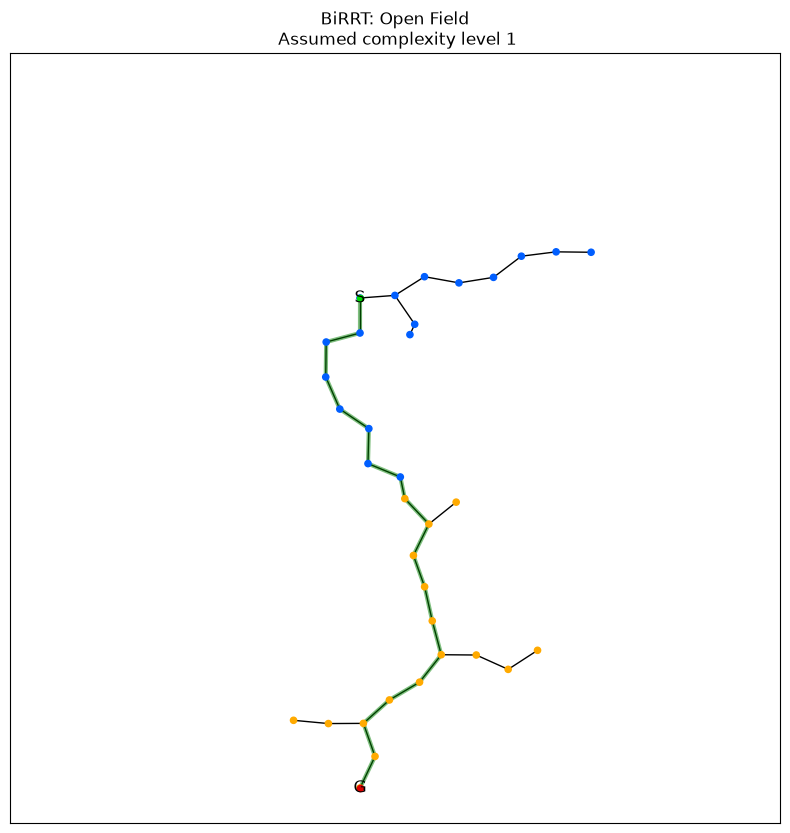

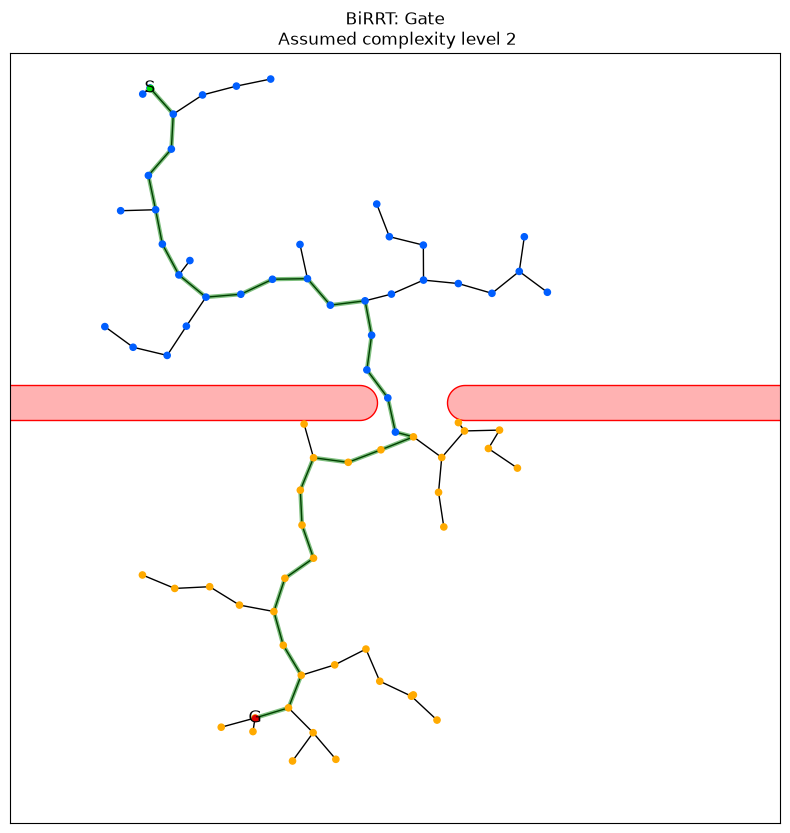

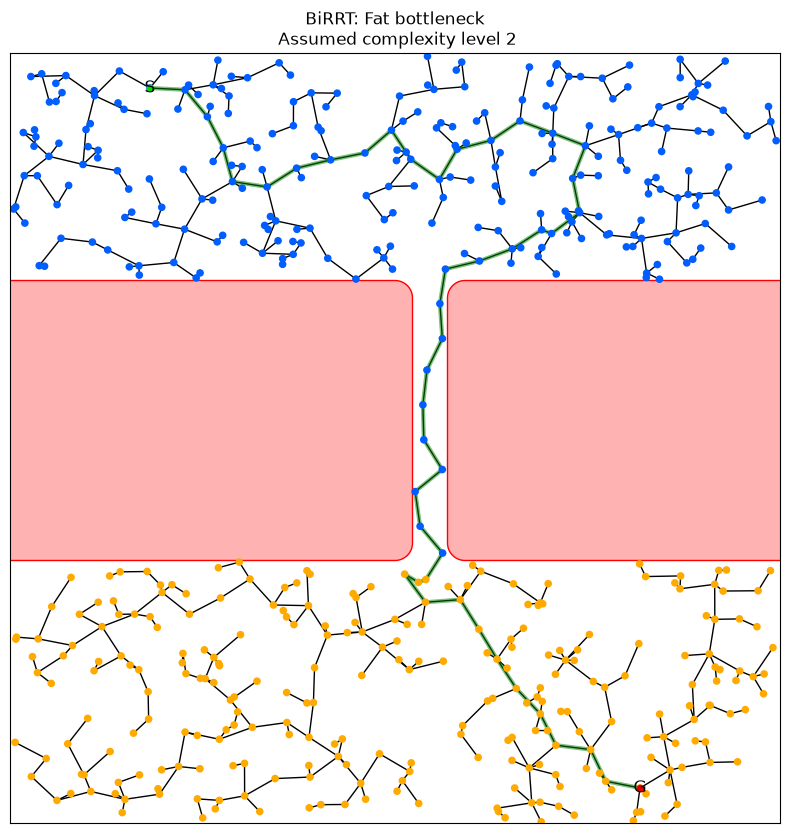

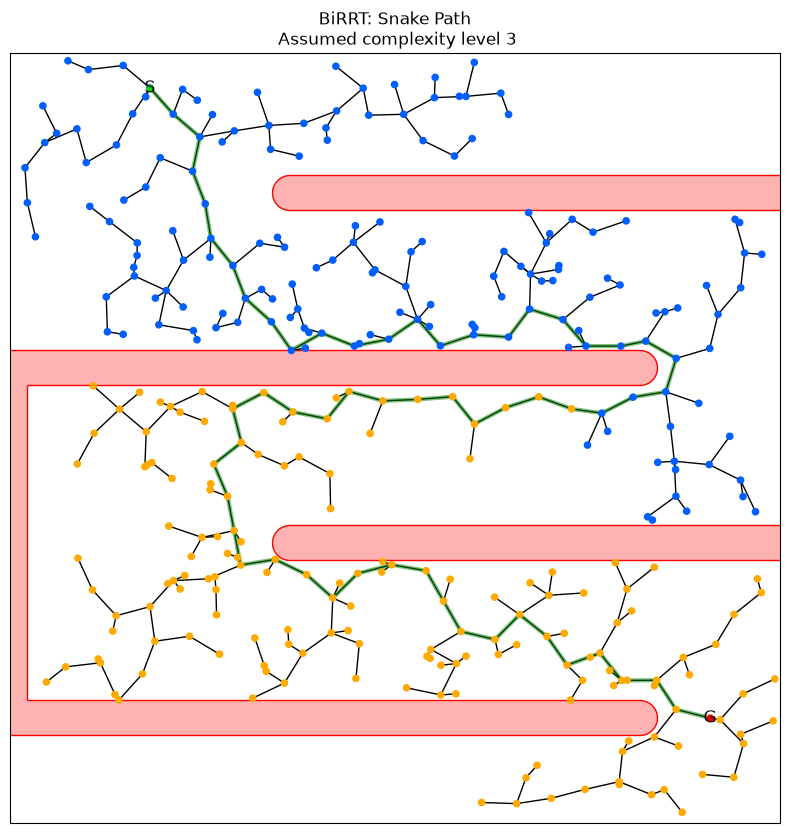

In [149]:
from BiRRT import BiRRT, BiRRTConfig
from lib.IPPerfMonitor import IPPerfMonitor


from lib.IPVISRRT import rrtPRMVisualize
from lib.IPPerfMonitor import IPPerfMonitor
from BenchmarkList import benchList
import matplotlib.pyplot as plt


birrtconfig = BiRRTConfig(
    stepSize=1,
    numberOfGeneratedNodes=1000,
    sampleGoalProbability=0.1,
    collisionDetectionSteps=10,
    maxIterations=2000,
    balanceTrees=True,
)


for benchmark in benchList:
    IPPerfMonitor.clearData()

    rrt = BiRRT(benchmark.collisionChecker)
    solution, err = rrt.planPath(benchmark.startList, benchmark.goalList, birrtconfig)

    if err:
        print(f"Benchmark {benchmark.name} failed with error: {err}")

    fig_local = plt.figure(figsize=(10,10))
    ax = fig_local.add_subplot(1,1,1)
    title = f"BiRRT: {benchmark.name}"
    if solution == []:
        title += " (No path found!)"
    title += "\n Assumed complexity level " + str(benchmark.level)
    
    ax.set_title(title)
    rrtPRMVisualize(rrt, solution, ax=ax, nodeSize=20)

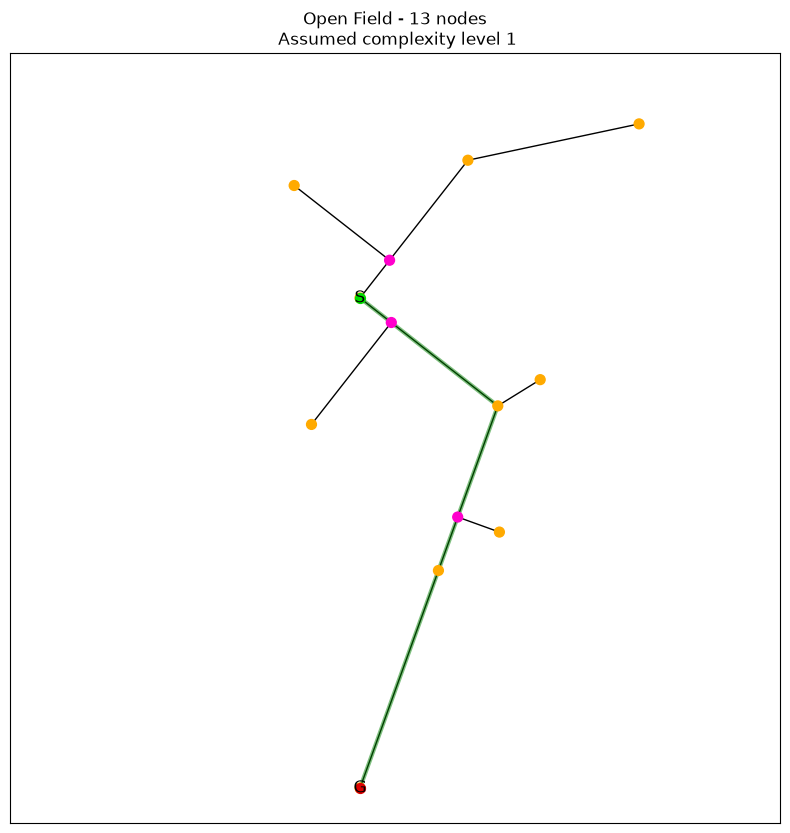

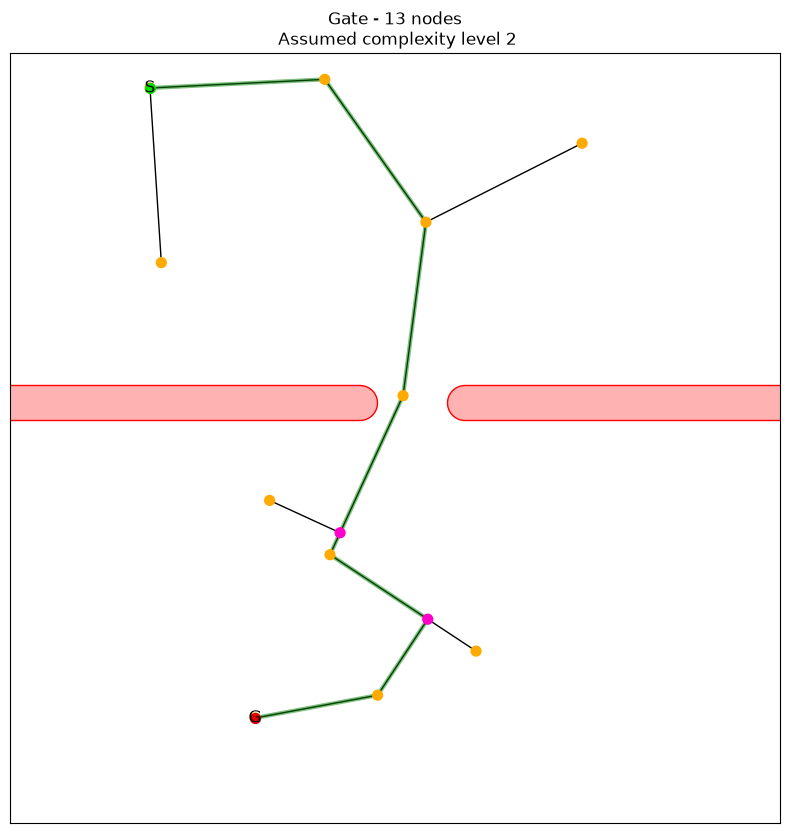

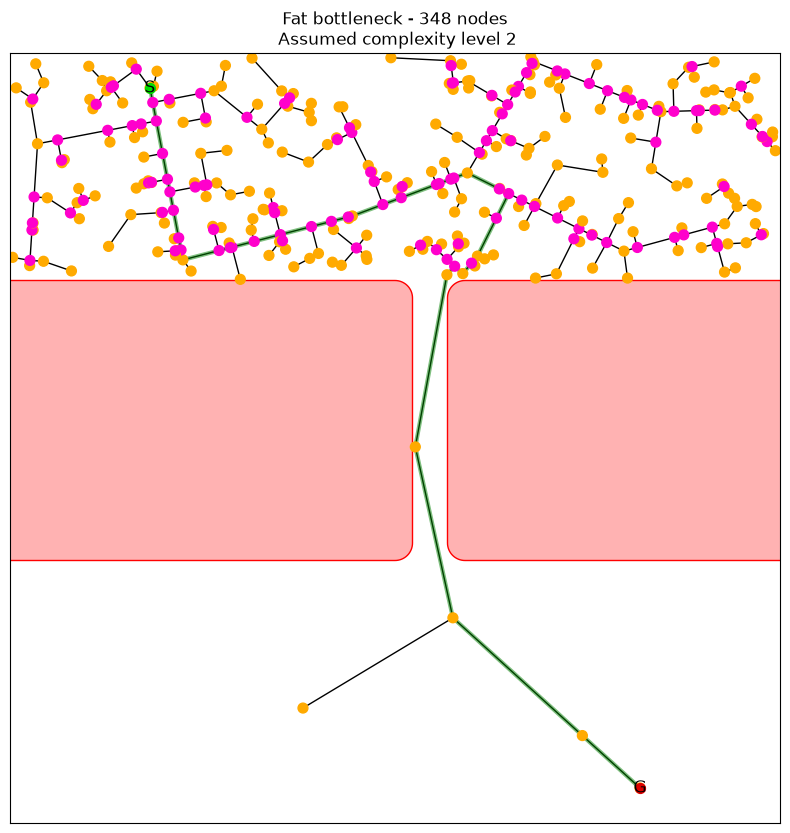

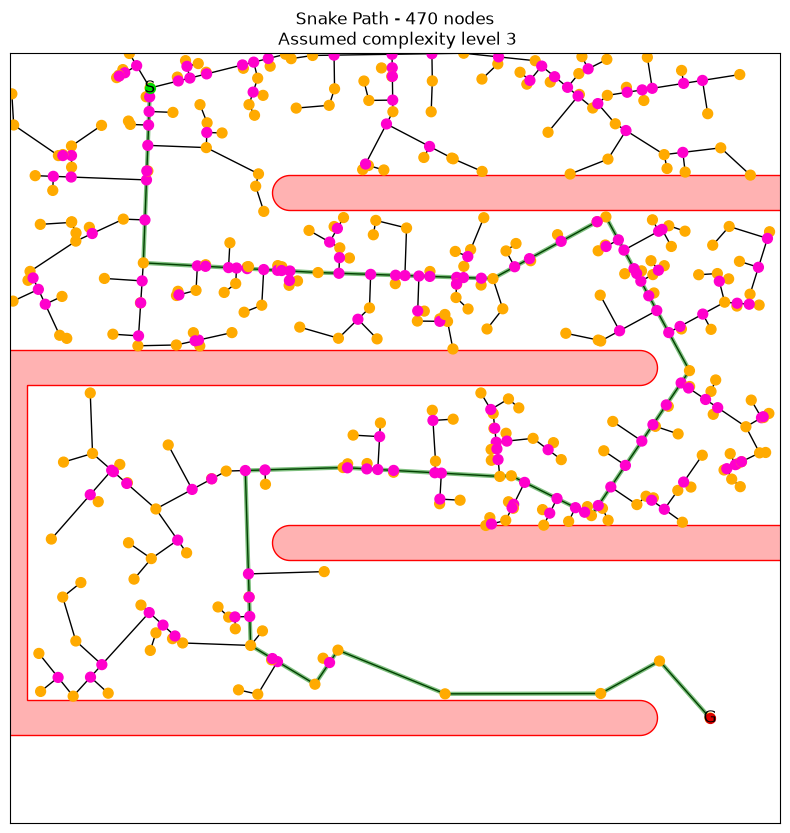

In [150]:
from RRT_with_Edge_sampling import RRTEdge, RRTEdgeConfig
from lib.IPPerfMonitor import IPPerfMonitor
from lib.IPVISRRT import rrtPRMVisualize
from lib.IPPerfMonitor import IPPerfMonitor
from BenchmarkList import benchList
import matplotlib.pyplot as plt


rrtedgeConfig = RRTEdgeConfig({
    'stepSize': 5,
    'testGoalAfterNumberOfNodes': 12,
    'numberOfGeneratedNodes': 500,
    'sampleGoalProbability': 0.2,
    'maxIterations': 5000,
    'orthogonalityMargin': 0.1,
    'collisionDetectionSteps': 10
})


for benchmark in benchList:
    IPPerfMonitor.clearData()

    rrt = RRTEdge(benchmark.collisionChecker)
    solution, err = rrt.planPath(benchmark.startList, benchmark.goalList, rrtedgeConfig)

    if err:
        print(f"Benchmark {benchmark.name} failed with error: {err}")

    fig_local = plt.figure(figsize=(10,10))
    ax = fig_local.add_subplot(1,1,1)
    title = f"{benchmark.name} - {rrt.graph.number_of_nodes()} nodes"
    if solution == []:
        title += " (No path found!)"
    title += "\n Assumed complexity level " + str(benchmark.level)
    
    ax.set_title(title)
    rrtPRMVisualize(rrt, solution, ax=ax,drawLabels=False)
    df = IPPerfMonitor.dataFrame()

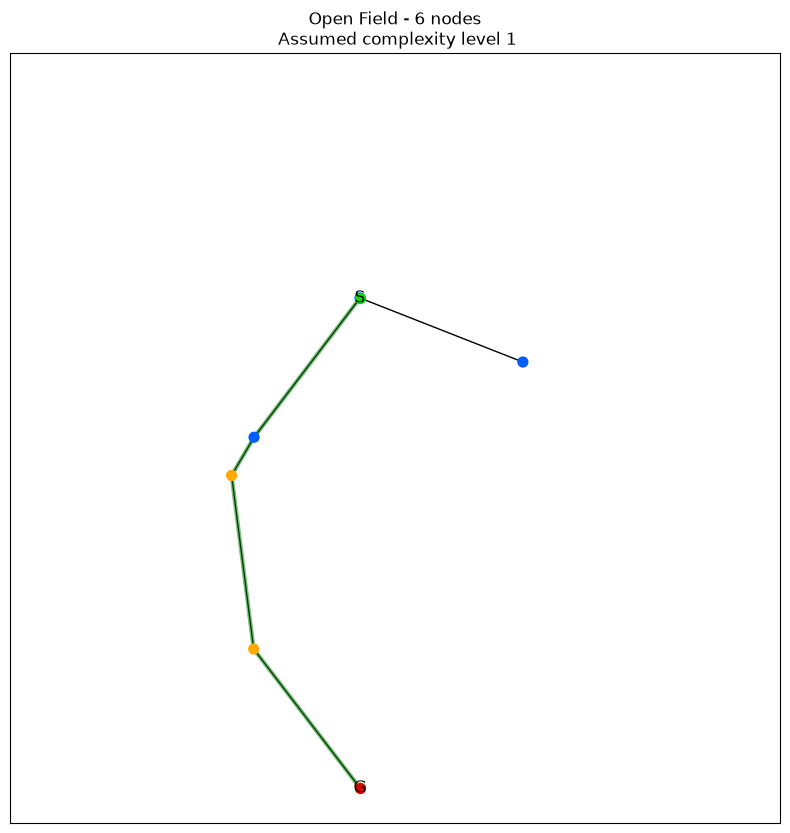

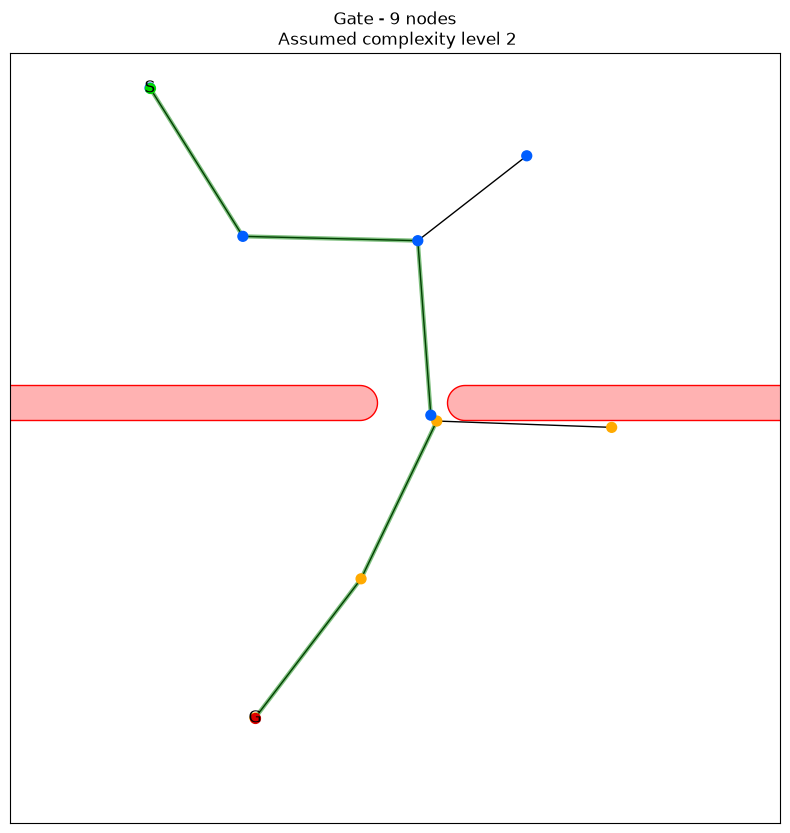

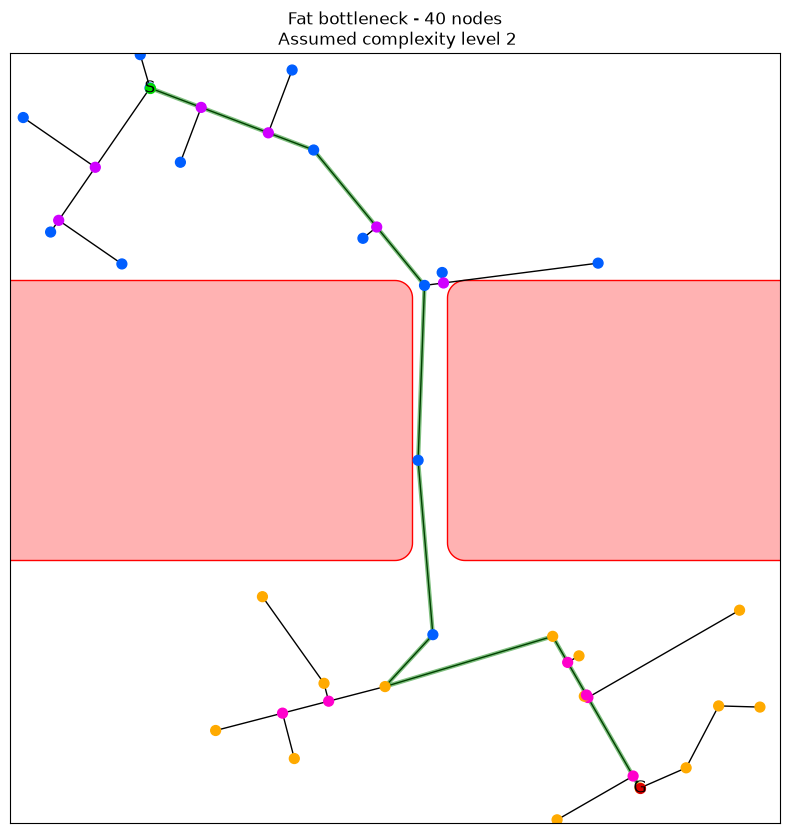

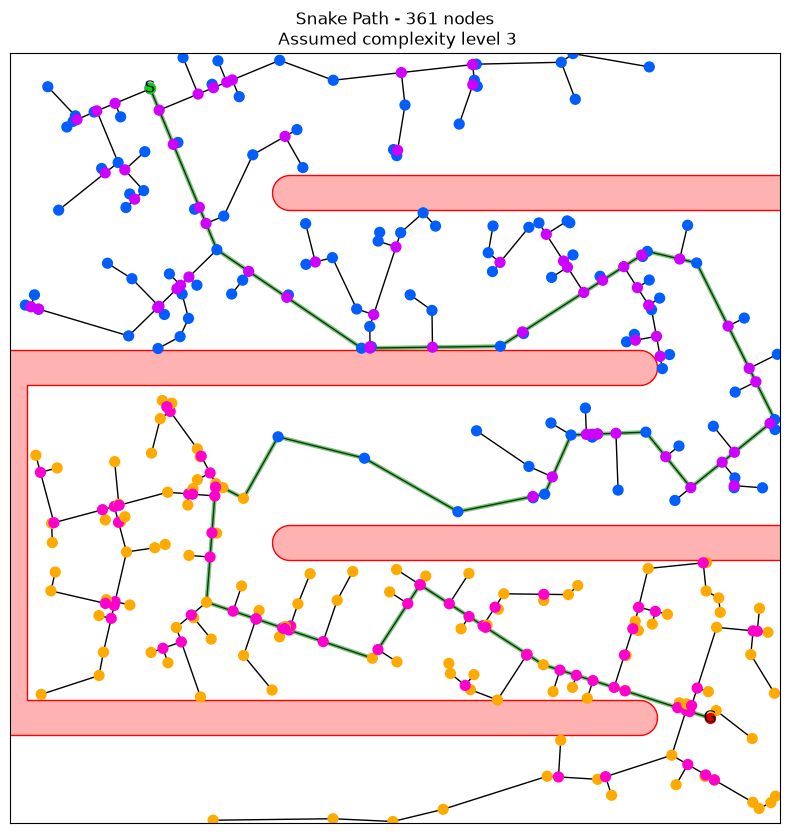

In [151]:
from BiRRT_with_Edge_sampling import BiRRTEdge, BiRRTEdgeConfig
from lib.IPPerfMonitor import IPPerfMonitor
from lib.IPVISRRT import rrtPRMVisualize
from lib.IPPerfMonitor import IPPerfMonitor
from BenchmarkList import benchList
import matplotlib.pyplot as plt


birrtedgeConfig = BiRRTEdgeConfig({
    'stepSize': 5,
    'balanceTrees': True,
    'numberOfGeneratedNodes': 500,
    'sampleGoalProbability': 0.0,
    'maxIterations': 5000,
    'orthogonalityMargin': 0.0,
    'collisionDetectionSteps': 10
})

for benchmark in benchList:
    IPPerfMonitor.clearData()

    rrt = BiRRTEdge(benchmark.collisionChecker)
    solution, err = rrt.planPath(benchmark.startList, benchmark.goalList, birrtedgeConfig)

    if err:
        print(f"Benchmark {benchmark.name} failed with error: {err}")

    fig_local = plt.figure(figsize=(10,10))
    ax = fig_local.add_subplot(1,1,1)
    title = f"{benchmark.name} - {rrt.graph.number_of_nodes()} nodes"
    if solution == []:
        title += " (No path found!)"
    title += "\n Assumed complexity level " + str(benchmark.level)

    ax.set_title(title)
    rrtPRMVisualize(rrt, solution, ax=ax)
                    


## 8. 2-DoF Varianten Vergleich

_Autor & Implementierung: Alisa Hummel_
### 8.1 Experimente

In [ ]:
# Imports and Utility Functions
import traceback
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import defaultdict
import math
from typing import Any, Dict, List, Tuple, Optional

from lib.IPRRT import RRTSimple, RRT
from RRT_with_Edge_sampling import RRTEdge, RRTEdgeConfig
from BiRRT import BiRRT, BiRRTConfig
from BiRRT_with_Edge_sampling import BiRRTEdge, BiRRTEdgeConfig

from lib.IPVISRRT import rrtPRMVisualize
from lib.IPPerfMonitor import IPPerfMonitor
from BenchmarkList import benchList

class ResultCollection (object):
    
    def __init__(self, plannerFactoryName, id, planner, benchmark, solution, perfDataFrame):
        self.plannerFactoryName = plannerFactoryName
        self.id = id
        self.planner = planner
        self.benchmark = benchmark
        self.solution = solution
        self.perfDataFrame = perfDataFrame

# Utility Functions for Stats
def path_length(solution, graph) -> float:
    positions = [graph.nodes[node]["pos"] for node in solution]
    
    total = 0.0
    for p1, p2 in zip(positions, positions[1:]):
        total += math.dist(p1, p2)
    
    return total

def group_by_planner_and_benchmark(results: List[ResultCollection]) -> Dict[Tuple[str, str], List[ResultCollection]]:
    groups: Dict[Tuple[str, str], List[ResultCollection]] = defaultdict(list)
    for result in results:
        groups[(result.plannerFactoryName, result.benchmark)].append(result)
    return groups

def calculate_statistics(resultList: List[ResultCollection]) -> pd.DataFrame:
    grouped = group_by_planner_and_benchmark(resultList)

    rows: List[dict] = []
    for (planner_name, benchmark), runs in grouped.items():
        # 1. Erfolgsrate
        # Durchläufe (Runs) filtern damit nur erfolgreiche für die spezifischen Statistikwerte zählen können
        successful_runs = [r for r in runs if len(r.solution) != 0]
        success_rate = len(successful_runs) / len(runs)

        unsuccessful_runs = [r for r in runs if len(r.solution) == 0]

        if unsuccessful_runs:
            # 2. Planungszeit
            planpath_unsuccessful_times = [
                r.perfDataFrame[r.perfDataFrame["name"] == "planPath"]["time"].iloc[0]
                for r in unsuccessful_runs
            ]
            avg_planpath_unsuccessful_times = sum(planpath_unsuccessful_times) / len(planpath_unsuccessful_times) 
        else:
            avg_planpath_unsuccessful_times = float("nan")

        if successful_runs:
            # 2. Planungszeit
            planpath_successful_times = [
                r.perfDataFrame[r.perfDataFrame["name"] == "planPath"]["time"].iloc[0]
                for r in successful_runs
            ]
            avg_planpath_successful_times = sum(planpath_successful_times) / len(planpath_successful_times)

            # 3. Anzahl erzeugter Knoten
            avg_num_nodes = sum(r.planner.graph.number_of_nodes() for r in successful_runs) / len(successful_runs)

            # 4. Anzahl Kanten
            avg_num_edges = sum(r.planner.graph.size() for r in successful_runs) / len(successful_runs)

            # 5. Anzahl aufgeteilter Kanten
            divide_edge_counts = [
                (r.perfDataFrame["name"] == "divide_edge").sum()
                for r in successful_runs
            ]
            avg_divide_edge = sum(divide_edge_counts) / len(divide_edge_counts)

            # 6. Anzahl Kollisionsprüfungen
            collision_check_counts = [
                (r.perfDataFrame["name"] == "lineInCollision").sum()
                for r in successful_runs
            ]
            avg_collision_checks = sum(collision_check_counts) / len(collision_check_counts)

            # 7. Pfadlänge
            avg_path_length = sum(
                path_length(r.solution, r.planner.graph) for r in successful_runs
            ) / len(successful_runs)

    
            # 8. Anzahl Pfadsegmente
            avg_solution_length = sum((len(r.solution)-1) for r in successful_runs) / len(successful_runs)

            # 9. mittlere Distanz vom Sample zum gewählten Erweiterungspunkt
            # Dafür mitteln über die Distanz der Punkte von lineInCollision-Aufrufen (entsprechen Sample und Erweiterungspunkt)
            avg_distances = []
            for r in successful_runs:
                collision_rows = r.perfDataFrame[r.perfDataFrame["name"] == "lineInCollision"]
                distances = [
                    math.dist(args[1], args[2])
                    for args in collision_rows["args"]
                ]
                if distances:
                    avg_distances.append(sum(distances) / len(distances))
            
            avg_expand_distance = (
                sum(avg_distances) / len(avg_distances)
                if avg_distances else float("nan")
            )

            # 10. Anteil der Erweiterungen, die von einer Kante statt von einem vorhandenen Knoten starten
            # Anzahl_Kanten = 1 Kante * Knoten_Erweiterung + 2 Kanten * Kanten_Erweiterung
            # Anzahl Kanten_Erweiterung durch divide_edge_count gegeben
            # Anzahl Knoten_Erwejterung = Anzahl_Kanten - 2 * Kanten_Erweiterung
            # Verhältnis = Kanten_Erweiterung / (Knoten_Erweiterung + Kanten_Erweiterung)
            edge_extension_ratios = [
                count / (r.planner.graph.size() - count)
                for r, count in zip(successful_runs, divide_edge_counts)
                if (r.planner.graph.size() - count) != 0
            ]
            avg_edge_extension_ratio = (
                sum(edge_extension_ratios) / len(edge_extension_ratios)
                if edge_extension_ratios else float("nan")
            )
       
        else:
            avg_planpath_successful_times = float("nan")
            avg_num_nodes = float("nan")
            avg_num_edges = float("nan")
            avg_divide_edge = float("nan")
            avg_collision_checks = float("nan")
            avg_path_length = float("nan")
            avg_solution_length = float("nan") 
            avg_expand_distance = float("nan")  
            avg_edge_extension_ratio = float("nan")    
            
        rows.append({
            "plannerName": planner_name,
            "benchmark": benchmark.name,
            "runs": len(runs),
            "sucess_rate": success_rate,
            "avg_time_unsuccessful": avg_planpath_unsuccessful_times,
            "avg_time_success": avg_planpath_successful_times,
            "avg_num_nodes": avg_num_nodes,
            "avg_num_edges": avg_num_edges,
            "divide_edge_calls": avg_divide_edge,
            "line_collision_checks": avg_collision_checks,
            "avg_path_length": avg_path_length,
            "avg_path_segments": avg_solution_length,
            "avg_expand_distance" : avg_expand_distance,
            "avg_edge_extension_ratio" : avg_edge_extension_ratio,
        })
    
    return pd.DataFrame(rows)

def shortest_path_per_group(
    results: List[ResultCollection],
) -> Dict[Tuple[str, str], ResultCollection]:
    grouped = group_by_planner_and_benchmark(results)
    
    shortest: Dict[Tuple[str, str], ResultCollection] = {}
    for (planner_name, benchmark), runs in grouped.items():
        successful_runs = [r for r in runs if len(r.solution) != 0]
        
        if not successful_runs:
            continue  # skip groups with no successful run
        
        shortest[(planner_name, benchmark)] = min(
            successful_runs,
            key=lambda r: path_length(r.solution, r.planner.graph),
        )
    
    return shortest

# Utility Functions for Plotting
def plot_table(table: pd.DataFrame, title: Optional[str] = None) -> None:
    fig, ax = plt.subplots(figsize=(len(table.columns) * 1.5, len(table) * 0.5 + 1))
    ax.axis("off")
    
    if title:
        ax.set_title(title, fontsize=14, weight="bold", pad=20)
    
    mpl_table = ax.table(
        cellText=table.round(3).values,
        colLabels=table.columns,
        cellLoc="center",
        loc="center",
    )
    
    mpl_table.auto_set_font_size(False)
    mpl_table.set_fontsize(10)
    mpl_table.scale(1, 1.5)
    mpl_table.auto_set_column_width(col=list(range(len(table.columns))))

    # Highlight header
    for col_idx in range(len(table.columns)):
        mpl_table[0, col_idx].set_facecolor("#40466e")
        mpl_table[0, col_idx].set_text_props(color="white", weight="bold")

    # Allign collumn "plannerName" left
    if "plannerName" in table.columns:
        planner_col_idx = table.columns.get_loc("plannerName")
        for row_idx in range(1, len(table) + 1):  # ab 1, um Header-Zeile auszuschließen
            cell = mpl_table[row_idx, planner_col_idx]
            cell.set_text_props(ha="left")
            cell.PAD = 0.03
    
    plt.tight_layout()
    plt.show()

def plot_tables_per_benchmark(table: pd.DataFrame, title: Optional[str] = "") -> None:
    for benchmark, group in table.groupby("benchmark"):
        group = group.drop(columns=["benchmark"]).reset_index(drop=True)
        plot_table(group, title=(title + str(benchmark)))

In [ ]:
# Adding and Configure all Planners
NUM_REPETITIONS = 30

def get_planner_config_set(nbOGeneratedNodes: int, testGoalAfterNbONodes: int, stepSize: float, goalBias: float, orthoMargin: float, 
                           maxIterations: int = 5000, collisionDetectionSteps: int = 20) -> Dict:
    plannerFactory = dict()

    rrtSimpleConfig = dict()
    rrtSimpleConfig["numberOfGeneratedNodes"] = nbOGeneratedNodes
    rrtSimpleConfig["testGoalAfterNumberOfNodes"]  = testGoalAfterNbONodes
    plannerFactory["1_RRTSimple"] = [RRTSimple, rrtSimpleConfig, rrtPRMVisualize]

    rrtConfig = dict()
    rrtConfig["numberOfGeneratedNodes"] = nbOGeneratedNodes
    rrtConfig["testGoalAfterNumberOfNodes"]  = testGoalAfterNbONodes
    plannerFactory["2_RRT"] = [RRT, rrtConfig, rrtPRMVisualize]

    rrtEdgeConfig = RRTEdgeConfig()
    rrtEdgeConfig["numberOfGeneratedNodes"] = nbOGeneratedNodes
    rrtEdgeConfig["testGoalAfterNumberOfNodes"] = testGoalAfterNbONodes
    rrtEdgeConfig["stepSize"] = stepSize
    rrtEdgeConfig["sampleGoalProbability"] = 0.0
    rrtEdgeConfig["collisionDetectionSteps"] = collisionDetectionSteps
    rrtEdgeConfig["maxIterations"] = maxIterations
    rrtEdgeConfig["orthogonalityMargin"] = orthoMargin
    plannerFactory["3_RRTEdge"] = [RRTEdge, rrtEdgeConfig, rrtPRMVisualize]

    if (goalBias != 0.0):
        rrtEdgeConfig = RRTEdgeConfig()
        rrtEdgeConfig["numberOfGeneratedNodes"] = nbOGeneratedNodes
        rrtEdgeConfig["testGoalAfterNumberOfNodes"] = testGoalAfterNbONodes
        rrtEdgeConfig["stepSize"] = stepSize
        rrtEdgeConfig["sampleGoalProbability"] = goalBias
        rrtEdgeConfig["collisionDetectionSteps"] = collisionDetectionSteps
        rrtEdgeConfig["maxIterations"] = maxIterations
        rrtEdgeConfig["orthogonalityMargin"] = orthoMargin
        plannerFactory["3_RRTEdge_GoalProb"] = [RRTEdge, rrtEdgeConfig, rrtPRMVisualize]

    birrtConfig = BiRRTConfig()
    birrtConfig["numberOfGeneratedNodes"] = nbOGeneratedNodes
    birrtConfig["stepSize"] = stepSize
    birrtConfig["balanceTrees"] = True
    birrtConfig["sampleGoalProbability"] = 0.0
    birrtConfig["collisionDetectionSteps"] = collisionDetectionSteps
    birrtConfig["maxIterations"] = maxIterations
    plannerFactory["4_BiRRT"] = [BiRRT, birrtConfig, rrtPRMVisualize]

    birrtEdgeConfig = BiRRTEdgeConfig()
    birrtEdgeConfig["numberOfGeneratedNodes"] = nbOGeneratedNodes
    birrtEdgeConfig["stepSize"] = stepSize
    birrtEdgeConfig["balanceTrees"] = True
    birrtEdgeConfig["sampleGoalProbability"] = 0.0
    birrtEdgeConfig["collisionDetectionSteps"] = collisionDetectionSteps
    birrtEdgeConfig["maxIterations"] = maxIterations
    birrtEdgeConfig["orthogonalityMargin"] = orthoMargin
    plannerFactory["5_BiRRTEdge"] = [BiRRTEdge, birrtEdgeConfig, rrtPRMVisualize]

    if (goalBias != 0.0):
        birrtEdgeConfig = BiRRTEdgeConfig()
        birrtEdgeConfig["numberOfGeneratedNodes"] = nbOGeneratedNodes
        birrtEdgeConfig["stepSize"] = stepSize
        birrtEdgeConfig["balanceTrees"] = True
        birrtEdgeConfig["sampleGoalProbability"] = 0.1
        birrtEdgeConfig["collisionDetectionSteps"] = collisionDetectionSteps
        birrtEdgeConfig["maxIterations"] = maxIterations
        birrtEdgeConfig["orthogonalityMargin"] = orthoMargin
        plannerFactory["5_BiRRTEdge_GoalProb"] = [BiRRTEdge, birrtEdgeConfig, rrtPRMVisualize]

    return plannerFactory

def run_planners(plannerFactory: Dict) -> List:
    resultList = list()
    for key,producer in list(plannerFactory.items()):
        for benchmark in benchList:
            for i in range(0, NUM_REPETITIONS):
                print ("Planning: " + key + " - " + benchmark.name + " - repetition:" + str(i+1))
                planner = producer[0](benchmark.collisionChecker)
                IPPerfMonitor.clearData()
                try:
                    resultList.append(ResultCollection(key,
                                                i,
                                                planner, 
                                                benchmark, 
                                                res[0] if isinstance(res := planner.planPath(benchmark.startList,benchmark.goalList,producer[1]), tuple) else res,
                                                IPPerfMonitor.dataFrame()
                                                ),
                                )
                    #print(resultList[-1].solution)
                    #print(resultList[-1].perfDataFrame)
                except Exception as e:
                #    throw e
                    print ("PLANNING ERROR ! PLANNING ERROR ! PLANNING ERROR ", e)
                    print(traceback.format_exc())
                    pass

    return resultList


# Define Configs
plannerFactories = dict()
plannerFactories["Optimal Parameter"] = get_planner_config_set(500, 12, 5, 0.2, 0.0)
plannerFactories["Lower StepSize"] = get_planner_config_set(500, 12, 2.5, 0.2, 0.0)
plannerFactories["Lower MaxNumNodes"] = get_planner_config_set(250, 12, 5, 0.2, 0.0)
plannerFactories["Higher TestGoalFreq"] = get_planner_config_set(500, 50, 5, 0.2, 0.0)

# Run Planners
resultLists = dict()
for key, plannerFactory in list(plannerFactories.items()):
    resultLists[key] = run_planners(plannerFactory)

Für die verschiedenen Planer wird, wie aus der Vorlesung im Notebook `IP-X-1-Automated_PlanerTest.ipynb`, automatisiert die planPath-Methode mit vorgegebener Konfiguration und Anzahl Wiederholungen ausgeführt. Der Planer, die Benchmarkumgebung, das Ergebnis, der DataFrame des Planers und eine ID als Indikator für die entsprechende Nummer an Wiederholung werden als Objekt `ResultCollection` für jeden Durchlauf in einer Liste gespeichert. 
Zur Statistikerhebung werden im nächsten Abschnitt die Durchläufe in der Methode `calculate_statistics(results: List[ResultCollection])` gruppiert pro Benchmark und Planer. Für jede Gruppe werden über die gespeicherten Daten die gewünschten Statistikwerte als Durchschnitt von allen Wiederholungen des Planers in gleicher Benchmark Umgebung berechnet und anschließend mit Methode `plot_tables_per_benchmark(table: pd.DataFrame)` als Tabellen ausgegeben. 

Als Planer verglichen werden:
* knotenbasierter RRT - `RRTSimple` (ohne begrenzte Schrittweite)
* knotenbasierter RRT - `RRT` (relative Schrittweite 0.5)
* kantenbasierte RRT - `RRTEdge`
    * ohne Goal-Bias-Wahrscheinlichkeit (=0.0)
    * mit Goal-Bias-Warhscheinlichkeit
* bidirektionaler, knotenbasierter RRT - `BiRRT`
* bidirektionaler, kantenbasierter RRT - `BiRRTEdge`
    * ohne Goal-Bias-Wahrscheinlichkeit (=0.0)
    * mit Goal-Bias-Warhscheinlichkeit

Als Konfigurationen für die Planer wurden vier Sets gewählt. 
1) Optimalen Paramtern des RRTEdge gefunden in Kapitel 7. 
    * numberOfGeneratedNodes = 500
    * testGoalAfterNumberOfNodes = 12
    * stepSize = 5
    * sampleGoalProbability = 0.2
2) Reduzierte StepSize: stepSize = 2.5
3) Reduzierte Anzahl an maximalen Knoten: numberOfGeneratedNodes = 250
4) Erhöhte Anzahl nach wie vielen Knoten Ziel getestet wird: testGoalAfterNumberOfNodes = 50

Die berechneten Statistik umfassen pro Planer und Benchmark die Metriken:
1. Erfolgsrate (sucess_rate),
2. Planungszeit für nicht-erfolgreiche Versuche (avg_time_unsuccessful),
3. Planungszeit für erfolgreiche Versuche (avg_time_successful),
4. Anzahl erzeugter Knoten (avg_num_nodes),
5. Anzahl Kanten (avg_num_edges),
6. Anzahl aufgeteilter Kanten (divide_edge_calls),
7. Anzahl Kollisionsprüfungen (line_collision_checks),
8. Pfadlänge (avg_path_length),
9. Anzahl Pfadsegmente (avg_path_segments),
10. mittlere Distanz vom Sample zum gewählten Erweiterungspunkt (avg_expand_distance),
11. Anteil der Erweiterungen, die von einer Kante statt von einem vorhandenen Knoten starten (avg_edge_extension_ratio).

Für die Planungszeit wird separat über die erfolgreichen und nicht-erfolgreichen Versuche der Durchschnitt berechnet. Die anderen Werte (3.-10.) werden ausschließlich als Durchschnnitt über die erfolgreichen Durchläufen berechnet. Damit sollen die Planer bei erfolgreicher Planung besser vergleichbar werden. 

### 8.2 Statistiken, Ergebnisse

In [ ]:
# Calculate Statistics
for key, resultList in list(resultLists.items()):
    table_statistics = calculate_statistics(resultList)
    
    benchmark_order = ["Open Field", "Gate", "Fat bottleneck", "Snake Path"]
    table_statistics["benchmark"] = pd.Categorical(table_statistics["benchmark"], categories=benchmark_order, ordered=True)
    table_statistics = table_statistics.sort_values(by=["benchmark", "plannerName"]).reset_index(drop=True)
    
    plot_tables_per_benchmark(table_statistics, title=(str(key)+ " - "))


Die Statistiken werden pro Benchmark evaluiert, zuerst für die in Kapitel 7. bestimmten optimalen Parameter und dann für die variierten Parameter. Die referenzierten Statisiken befinden sich im Ordner `/Ergebnisse/2DoF_PointRobot` aufgeteilt in eine Tabelle für eine Konfigurationsgruppe pro Benchmark. Folgendes sind die Ergebnisse:

#### Offenes Feld
* Bei dieser Umgebung ohne Hindernisse haben alle Planer eine **Erfolgsrate** von 100%. 
* Mit optimalen Parametern sind die **Planungszeiten** der Planer ähnlich. Die kantenbasierten Planer RRTEdge und BiRRTEdge haben weniger Collision Checks als die knotenbasierten Planer, dafür aber den Projektionsaufwand und die Aufrufe der divide_edge-Methode. 
* Die unidirektionale, kantenbasierte Variante findet im Schnitt kürzere **Pfadlängen** als die knotenbasierte Variante. Das wird auch erkennbar, da 26–32 % der Erweiterungen kantenbasiert sind und somit tendentiell kürzer. Auch die bidirektionalen Varianten finden kürzere Pfade als die unidirektionalen, knotenbasierten Varianten. Wobei bei den bidirektionalen Planern die kanten- und knotenbasierten Varianten hier ähnlich abschneiden. 
* Sowohl bei der unidirektionalen als auch bei der bidirektionalen RRTEdge Variante bringt der **Goal-Bias** Vorteile in der Pfadlänge, weil der Baum direkter zum Ziel wächst. 
* Während die meisten unidirektionalen Varianten erst nach der Anzahl testGoalAfterNodes (12 Nodes) die Lösung berechnen, testen die bidirektionalen Planer nach jedem hinzugefügten Knoten die Verbindung der Teilbäume und haben damit im Schnitt mit weniger Knoten im Graphen eine Lösung gefunden.
* **Kleinere StepSize:** Verringert die Pfadlänge vom RRTEdge leicht, aber für die bidirektionalen Planer steigt die Planungszeit und die Anzahl an Knoten im Graphen. 
* **Reduzierte Anzahl maxNumberNodes:** ändert in diesem Fall nichts am Ergebnis, weil bereits vor der maximalen Anzahl an Knoten eine Lösung gefunden wird.
* **Höhere Anzahl testGoalAfterNodes:** Ist nur für die unidirektionalen Planer relevant, da die bidirektionalen Planer sowieso nach jedem hinzugefügten Knoten eine Verbindung überprüfen. Deshalb zeigt die höhere Anzahl hier große Nachteile für die knotenbasierten und kantenbasierten Planer. Es entstehen mehr Knoten im Graphen, obwohl wahrscheinlich auch schon früher eine Verbindung zum Zielknoten gefunden werden könnte, aber diese nicht getestet wird. Dadurch vervielfacht sich auch die Laufzeit. Für den RRTEdge bringt der Goal-Bias den Vorteil, dass im Schnitt schon vor der Anzahl von testGoalAfterNodes eine Lösung gefunden wird, weil das Goal gesampelt wurde und der Graph nah genug am Ziel war. Die kantenbasierte Variante mit Goal-Bias findet nach wie vor den kürzesten Weg. Auch die bidirektionalen Varianten schneiden in der Pfadlänge wieder besser als die unidirektionalen, knotenbasierten Varianten ab. 

#### Schmale Engstelle
* Auch hier haben die Planer alle eine **Erfolgsrate** von an die 100 %.
* Mit optimalen Parametern haben die unidirektionalen, kantenbasierten Planer kürzere **Planungszeiten** als die knotenbasierten mit weniger Collision Checks. Auch die bidirektionalen Planer haben kürzere Planungszeiten und weniger Knoten im Graphen als die unidirektionalen, knotenbasierten und kantenbasierten Planer. 
* Der kantenbasierte RRTEdge ohne Goal-Bias findet die kürzeste **Pfadlänge**, gefolgt vom RRTEdge mit Goal-Bias. Aber auch der knotenbasierte RRT findet im Schnitt ähnlich kurze Pfade und vor allem kürzere als der knotenbasierte RRTSimple ohne Step Size. Das weist darauf hin, dass das Nutzen einer Step Size bei der Erweiterung vor allem für die unidirektionalen Planer sinnvoll ist. Trotz der guten Pfadlänge zeigt der knotenbasierte RRT den Nachteil in der höchsten Anzahl von Knoten im Graphen und der langsamsten Berechnung. 
* Die bidirektionalen Planer finden im Schnitt etwas längere Pfade, wobei der BiRRTEdge mit Goal-Bias im Schnitt ähnlich lange Pfade wie die unidirektionale Variante findet. Dabei sind die bidirektionalen Planer sogar eher schneller als die unidirektionalen Planer. 
* Der **Goal-Bias** bringt hier weniger Vorteile. Da der Start-/Zielknoten nicht direkt vor der Lücke liegt, blockieren die Hindernisse den Weg und die Planer benötigen mehr Knoten.
* **Kleinere StepSize:** Erhöht die Planungsdauer der unidirektionalen kantenbasierten Planer und der bidirektionalen Planer deutlich, vor allem weil mehr Knoten dem Graphen hinzugefügt werden und mehr Collision Checks durchgeführt werden. Wobei der Effekt bei den unidirektionalen größer ist als bei den bidirektionalen. Die resultierenden Pfadlängen sind ähnlich den Ergebnissen mit optimalen Parametern. Eine kleinere Step Size bringt hier also keinen Vorteil. Die unidirektionalen knotenbasierten RRT und RRTSimple nutzen keine vorgegebene Step Size, haben hier also eine schnellere Laufzeit als die anderen Planer.
* **Reduzierte Anzahl maxNumberNodes:** keinen Unterschied zu den Ergebnissen mit optimalen Parametern, weil immer noch schneller eine Lösung gefunden wird. 
* **Höherer Anzahl testGoalAfterNodes:** Für die unidirektionalen Planer steigen die Planungszeiten wieder deutlich, ebenso wie die durchschnittliche Anzahl an Knoten im Graphen und die Collision Checks. Die Pfadlänge bleibt allerdings ähnlich zu den Ergebnissen der optimalen Parametern.

#### Breite Engstelle
* Bei optimalen Parametern haben wieder alle Planer an die 100 % **Erfolgsquote** außer der knotenbasierten RRT mit 97 %. 
* Der kantenbasierte RRTEdge hat eine höhere **Planungszeit** als die knotenbasierten RRTSimple und RRT. Das muss vor allem an den Projektionsberechnungen und den divide_edge-Methodenaufrufen liegen, denn es werden nicht mehr Collision Checks durchgeführt.
* Bei diesem Experimentendurchlauf hatte der knotenbasierte RRT die kürzeste **Pfadlänge**, aber dicht gefolgt vom kantenbasierten RRTEdge mit Goal-Bias bei um die 50 % Kantenerweiterungen. Die bidirektionalen Planer schneiden etwas schlechter ab. Hier findet die kantenbasierte BiRRTEdge Variante mit und ohne Goal-Bias kürzere Pfade als die knotenbasierte BiRRT. Allerdings mit mehr Planungszeit.
* **Kleinere StepSize:** Damit haben die betroffenen Planer wieder eine höhere Planungsdauer mit mehr Knoten und mehr Collision Checks. Mit kleiner Step Size schneidet nun der RRTEdge ohne und mit Goal-Bias in der Pfadlänge wieder am Besten ab.
* **Reduzierte Anzahl maxNumberNodes:** Es sinkt die Erfolgsquote der Planer. Höchste Erfolgsquote mit 100 % haben der knotenbasierte RRTSimple und der knotenbasierte BiRRT. Diese haben allerdings auch die längsten Pfade im Schnitt. Die kürzesten Pfade finden nach wie vor der knotenbasierte RRT mit immerhin um die 93 % Erfolgsquote und der kantenbasierte RRTEdge mit Goal-Bias um die 87 % Erfolgsquote.
* **Höhere Anzahl testGoalAfterNodes:** Es steigt allgemein die Planungsdauer der unidirektionalen Planer wieder mit deutlich mehr Knoten im Graphen und mehr Collision Checks bei ähnlichen Pfadlängen.

#### Labyrinth
* Bei optimalen Parametern, haben die bidirektionalen Planer eine **Erfolgsquote** von 100 %. Überraschend ist, dass auch der RRTSimple ohne StepSize eine Erfolgsquote von 100 % zeigt. Der unidirektionale, knotenbasierte RRT mit um die 53 % hat eine etwas höhere Erfolgschance als die kantenbasierten. Der kantenbasierte RRTEdge mit Goal-Bias hat hier die schlechteste Erfolgsrate.
* Auch in der **Planungszeit** schlagen die bidirektionalen Planer die unidirektionalen. Die bidirektionalen kantenbasierten Planer zeigen hier höhere Planungszeiten mit mehr Knoten im Graphen als der bidirektionale knotenbasierte Planer.
* Die beste **Pfadlänge** haben wieder die kantenbasierten Planer mit Goal-Bias obwohl der Weg nicht auf das Ziel zugeht.
* **Kleinere StepSize:** Die Erfolgsquote der unidirektionalen, kantenbasierten Planer steigt etwas an. Aber auch die Planungszeiten erhöhen sich. Und auch hier ist keine signifikante Verbesserung der gefundenen Pfadlänge zu bemerken.
* **Reduzierte Anzahl maxNumberNodes:** Es sinkt die Erfolgsquote für alle Planer, aber weniger stark bei den bidirektionalen als bei den unidirektionalen. Für die erfolgreichen Planungen sinkt dafür auch die Planungszeit und minimal auch die Länge des gefundenen Pfades, vermutlich weil mehr Durchläufe herausgefiltert werden und nur die kürzeren, direkten in die Statistik einfließen. 
* **Höhere Anzahl testGoalAfterNodes:** Es sinkt für die unidirektionalen Planer wieder die Erfolgsrate, aber bei ähnlich bleibender Planungszeit. Die Pfadlängen der kantenbasierten RRTEdge verkürzen sich etwas.

#### Fazit
Die kantenbasierten Varianten finden sowohl bei unidirektionalen als auch bei bidirektionalen Planern tendenziell kürzere Pfade als die knotenbasierten Varianten. In einfachen Umgebungen (Open Field und Gate) ist ihre Planungszeit im Vergleich auch nicht länger. In komplexeren Umgebungen (Fat Bottleneck und Snake Path) schneiden die bidirektionalen Planer vor allem in der Erfolgsquote deutlich besser ab als die unidirektionalen. Die bidirektionale, kantenbasierte Variante liefert im Schnitt kürzere Pfade, aber mit deutlich längerer Planungszeit als die knotenbasierte Variante.

Der maxNumberNode ist vor allem bei komplexen Umgebungen ein limitierender Faktor, wobei die bidirektionalen Planer robuster reagieren. Eine höhere Anzahl von testGoalAfterNode führt zu einer geringeren Zieltest-Frequenz und erhöht damit die Planungszeit ohne signifikante Verbesserung der Pfadlänge. Das kann daran liegen, dass die Kosten für einen lineInCollion-Test um eine Lösung zu finden, geringer sind als die Iterationskosten um den Graphen zu erweitern. Eine kleinere Step Size kann die Erfolgsquote etwas verbessern, führt allerdings auch zu längeren Planungszeiten und mehr Knoten im Graphen. Der Goal-Bias der kantenbasierten Varianten verbessert die Länge des gefundenen Pfades weiter, auch in Umgebungen, in denen die Benchmark nicht einen direkten Weg in Richtung Zielknoten zulässt, z.B. Snake Path.

## 8.3 Visualisierung
Aus allen Durchläufen der Planer eines Konfigurationssets in einer Benchmark wird der Durchlauf mit dem kürzesten Pfad herausgefiltert und geplottet. Die Plots sind im Ordner `/Ergebnisse/2DoF_PointRobot` zu finden.

In [ ]:
import matplotlib.pyplot as plt

first_key = next(iter(resultLists))
first_best_runs = shortest_path_per_group(resultLists[first_key])

# Reihenfolge wie im ersten Durchlauf zuerst aufgetaucht, ohne Duplikate
planner_names = list(dict.fromkeys(pn for pn, bm in first_best_runs.keys()))
benchmarks = list(dict.fromkeys(bm for pn, bm in first_best_runs.keys()))

for key, resultList in list(resultLists.items()):
    best_runs = shortest_path_per_group(resultList)

    n_rows = len(planner_names)
    n_cols = len(benchmarks)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), squeeze=False)

    for row, planner_name in enumerate(planner_names):
        for col, benchmark in enumerate(benchmarks):
            ax = axes[row][col]
            result = best_runs.get((planner_name, benchmark))

            if result is None:
                ax.axis("off")
                continue

            title = planner_name + " - " + benchmark.name
            ax.set_title(title)

            try:
                plannerFactories[key][result.plannerFactoryName][2](
                    result.planner, result.solution, ax=ax, nodeSize=100
                )
            except Exception as e:
                print("Error", e)
                ax.axis("off")

    fig.suptitle(str(key), fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    plt.close(fig)

## 9. N-DoF Planar Manipulator
_Autor: Loretta Jacobs_
### 9.1 Experimente

In [ ]:

import matplotlib.pyplot as plt
from shapely.geometry import LineString

from lib.IPRRT import RRT
from RRT_with_Edge_sampling import RRTEdge, RRTEdgeConfig
from BiRRT_with_Edge_sampling import BiRRTEdge, BiRRTEdgeConfig

from lib.IPBenchmark import Benchmark
from lib.IPPlanarManipulator import PlanarRobot
from lib.IPEnvironmentKin import KinChainCollisionChecker
from lib.IPPerfMonitor import *
from lib.IPEnvironmentKin import animateSolution
from lib.IPVISRRT import *
from lib.IPEnvironmentKin import planarRobotVisualize

In [ ]:
class ResultCollection (object):
    
    def __init__(self, plannerFactoryName, id, planner, benchmark, solution, perfDataFrame):
        self.plannerFactoryName = plannerFactoryName
        self.id = id
        self.planner = planner
        self.benchmark = benchmark
        self.solution = solution
        self.perfDataFrame = perfDataFrame

In [ ]:
def gatherData(resultList: List[ResultCollection]) -> pd.DataFrame:
    rows: List[dict] = []
    for result in resultList:

        # 2. Planungszeit
        planPathTime = result.perfDataFrame[result.perfDataFrame["name"] == "planPath"]["time"].iloc[0]
            
        # 3. Anzahl erzeugter Knoten
        num_nodes = result.planner.graph.number_of_nodes()

        # 4. Anzahl Kanten
        num_edges = result.planner.graph.size()

        # 5. Anzahl aufgeteilter Kanten
        divide_edge_counts = (result.perfDataFrame["name"] == "divide_edge").sum()

        # 6. Anzahl Kollisionsprüfungen
        collision_check_counts = (result.perfDataFrame["name"] == "lineInCollision").sum()

        # 7. Pfadlänge
        path_lengths = path_length(result.solution, result.planner.graph) 

        # 8. Anzahl Pfadsegmente
        solution_length = (len(result.solution)-1)

        # 9. mittlere Distanz vom Sample zum gewählten Erweiterungspunkt
        # Dafür mitteln über die Distanz der Punkte von lineInCollision-Aufrufen (entsprechen Sample und Erweiterungspunkt)
        collision_rows = result.perfDataFrame[result.perfDataFrame["name"] == "lineInCollision"]
        distances = [
            math.dist(args[1], args[2])
            for args in collision_rows["args"]
        ]
        if distances:
            avg_distances = (sum(distances) / len(distances))
        else:
            avg_distances = 0 
        

        # 10. Anteil der Erweiterungen, die von einer Kante statt von einem vorhandenen Knoten starten
        # Verhältnis = Kanten_Erweiterung / (Knoten_Erweiterung + Kanten_Erweiterung)
        edge_extension_ratio = divide_edge_counts / num_edges
        
        rows.append({
            "plannerName": result.plannerFactoryName,
            "benchmark": result.benchmark.name,
            "planpath_time": planPathTime,
            "num_nodes": num_nodes,
            "num_edges": num_edges,
            "divide_edges_calls": divide_edge_counts,
            "line_collision_checks": collision_check_counts,
            "path_length": path_lengths,
            "solution_length": solution_length,
            "avg_expand_distance" : avg_distances,
            "edge_extension_ratio" : edge_extension_ratio,
        })
    
    return pd.DataFrame(rows)

In [ ]:
def getPlanners4() -> dict[str, Any]:
    plannerFactory = dict()

    nbOGeneratedNodes = 500
    testGoalAfterNbONodes = 12
    stepSize = 4
    sampleGoalProbability = 0.2
    orthogonalityMargin = 0.1
    collisionDetectionSteps = 10
    maxIt = 5000

    rrtConfig = dict()
    rrtConfig["numberOfGeneratedNodes"] = nbOGeneratedNodes
    rrtConfig["testGoalAfterNumberOfNodes"]  = testGoalAfterNbONodes
    plannerFactory["RRT"] = [RRT, rrtConfig, rrtPRMVisualize]

    rrtEdgeConfig = RRTEdgeConfig(
        numberOfGeneratedNodes=nbOGeneratedNodes,
        testGoalAfterNumberOfNodes=testGoalAfterNbONodes,
        stepSize=stepSize,
        sampleGoalProbability=sampleGoalProbability,
        orthogonalityMargin=orthogonalityMargin,
        maxIterations=maxIt,
        collisionDetectionSteps=collisionDetectionSteps,
    )
    plannerFactory["RRTEdge"] = [RRTEdge, rrtEdgeConfig, rrtPRMVisualize]

    birrtConfig = BiRRTConfig(
        stepSize=stepSize,
        balanceTrees=True,
        numberOfGeneratedNodes=nbOGeneratedNodes,
        sampleGoalProbability=sampleGoalProbability,
        maxIterations=maxIt,
        collisionDetectionSteps=collisionDetectionSteps,
    )
    plannerFactory["BiRRT"] = [BiRRT, birrtConfig, rrtPRMVisualize]

    birrtEdgeConfig = BiRRTEdgeConfig(
        stepSize=stepSize,
        balanceTrees=True,
        numberOfGeneratedNodes=nbOGeneratedNodes,
        sampleGoalProbability=sampleGoalProbability,
        maxIterations=maxIt,
        collisionDetectionSteps=collisionDetectionSteps,
        orthogonalityMargin=orthogonalityMargin
    )
    plannerFactory["BiRRTEdge"] = [BiRRTEdge, birrtEdgeConfig, rrtPRMVisualize]

    return plannerFactory


def getPlanners6() -> dict[str, Any]:
    plannerFactory = dict()

    nbOGeneratedNodes = 500
    testGoalAfterNbONodes = 12
    stepSize = 4
    sampleGoalProbability = 0.1
    orthogonalityMargin = 0.2
    collisionDetectionSteps = 10
    maxIt = 5000

    rrtConfig = dict()
    rrtConfig["numberOfGeneratedNodes"] = nbOGeneratedNodes
    rrtConfig["testGoalAfterNumberOfNodes"]  = testGoalAfterNbONodes
    plannerFactory["RRT"] = [RRT, rrtConfig, rrtPRMVisualize]

    rrtEdgeConfig = RRTEdgeConfig(
        numberOfGeneratedNodes=nbOGeneratedNodes,
        testGoalAfterNumberOfNodes=testGoalAfterNbONodes,
        stepSize=stepSize,
        sampleGoalProbability=sampleGoalProbability,
        orthogonalityMargin=orthogonalityMargin,
        maxIterations=maxIt,
        collisionDetectionSteps=collisionDetectionSteps,
    )
    plannerFactory["RRTEdge"] = [RRTEdge, rrtEdgeConfig, rrtPRMVisualize]

    birrtConfig = BiRRTConfig(
        stepSize=stepSize,
        balanceTrees=True,
        numberOfGeneratedNodes=nbOGeneratedNodes,
        sampleGoalProbability=sampleGoalProbability,
        maxIterations=maxIt,
        collisionDetectionSteps=collisionDetectionSteps,
    )
    plannerFactory["BiRRT"] = [BiRRT, birrtConfig, rrtPRMVisualize]

    birrtEdgeConfig = BiRRTEdgeConfig(
        stepSize=stepSize,
        balanceTrees=True,
        numberOfGeneratedNodes=nbOGeneratedNodes,
        sampleGoalProbability=sampleGoalProbability,
        maxIterations=maxIt,
        collisionDetectionSteps=collisionDetectionSteps,
        orthogonalityMargin=orthogonalityMargin
    )
    plannerFactory["BiRRTEdge"] = [BiRRTEdge, birrtEdgeConfig, rrtPRMVisualize]

    return plannerFactory

In [ ]:
planner_2_or_4_DoF = getPlanners4()
planner_6DoF = getPlanners6()

obst = dict()
obst["obs1"] = LineString([(-2, 0), (-0.8, 0)]).buffer(0.5)
obst["obs2"] = LineString([(2, 0), (2, 1)]).buffer(0.2)
obst["obs3"] = LineString([(-1, 2), (1, 2)]).buffer(0.1)

# planar robots
planarRobotDict = dict()
r_2 = PlanarRobot(n_joints=2)
start_joints_2 = [2.0, 0.5]
end_joints_2 = [-2.0, -0.5]
environment_2 = KinChainCollisionChecker(r_2, obst,fk_resolution=.2)
planarRobotDict["2DoF"] = [r_2, start_joints_2, end_joints_2, environment_2, planner_2_or_4_DoF]

r_4 = PlanarRobot(n_joints=4)
limits_4 = [[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14]]
start_joints_4 = [2.0, 0.5, 0.5, 0.5]
end_joints_4 = [-2.0, -0.5, -0.5,-0.5]
environment_4 = KinChainCollisionChecker(r_4, obst, limits= limits_4, fk_resolution=.2)
planarRobotDict["4DoF"] = [r_4, start_joints_4, end_joints_4, environment_4, planner_2_or_4_DoF]

r_6 = PlanarRobot(n_joints=6)
limits_6 = [[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14]]
start_joints_6 = [2.0, 0.5, 0.5, 0.5, 0.5, 0.5]
end_joints_6 = [-2.0, -0.5, -0.5,-0.5, -0.5, -0.5]
environment_6 = KinChainCollisionChecker(r_6, obst, limits= limits_6, fk_resolution=.2)
planarRobotDict["6DoF"] = [r_6, start_joints_6, end_joints_6, environment_6, planner_6DoF]


In [ ]:
import tqdm
maxIterations = 10
resultList = list()
for robotKey, robot in list(planarRobotDict.items()):
    start = [robot[1]]
    goal  = [robot[2]]

    benchmark = Benchmark(
            "Obst_" + robotKey,
            robot[3],
            start,
            goal,
            "Obst_" + robotKey,
            2,
        )
    
    for plannerKey, planner in list(robot[4].items()):
        for i in tqdm.tqdm(range(0, maxIterations), desc=f"Planning {plannerKey} for {robotKey}", unit="run"):

            IPPerfMonitor.clearData()

            rrt = planner[0](robot[3])
            try:
                
                resultList.append(ResultCollection(plannerKey,
                    0,
                    rrt, 
                    benchmark, 
                    res[0] if isinstance(res := rrt.planPath(start, goal, planner[1]), tuple) else res,
                    IPPerfMonitor.dataFrame()
                    ),
                )
            except Exception as e:
            #    throw e
                print ("PLANNING ERROR ! PLANNING ERROR ! PLANNING ERROR ", e)
                print(traceback.format_exc())
                pass
            ## plan path from start to goal



Resultate speichern / laden

In [ ]:
import dill
filename = "export/4_dof_resultList.pkl"
with open(filename, 'wb') as f:
    dill.dump(resultList, f)

In [ ]:
import dill
resultList = list()
filename = "./Ergebnisse/rohdaten/n_dof_resultList.pkl"
with open(filename, 'rb') as f:
    resultList = dill.load(f)

### 9.2 Statistiken, Ergebnisse

In [ ]:
statistics = gatherData(resultList) # Für einen Durchlauf
statistics = calculate_statistics(resultList) # Für mehrere Durchläufe
statistics

In [ ]:
plannerOrder = ["RRT", "RRTEdge", "BiRRT", "BiRRTEdge"]
statistics['plannerName'] = pd.Categorical(
    statistics['plannerName'], 
    categories=plannerOrder, 
    ordered=True
)

grp = statistics.query("benchmark == 'Obst_2DoF'").groupby(["benchmark", "plannerName"]).agg(
    time_mean=('planpath_time', 'mean'),
    num_nodes_mean=('num_nodes', 'mean'),
    #num_nodes_std=('num_nodes', 'std'),
    num_edges_mean=('num_edges', 'mean'),
    #num_edges_std=('num_edges', 'std'),
    divide_edges_calls_mean=('divide_edges_calls', 'mean'),
    #divide_edges_calls_std=('divide_edges_calls', 'std'),
    line_collision_checks_mean=('line_collision_checks', 'mean'),
    #line_collision_checks_std=('line_collision_checks', 'std'),
    path_length_mean=('path_length', 'mean'),
    #path_length_std=('path_length', 'std'),
    solution_length_mean=('solution_length', 'mean'),
    #solution_length_std=('solution_length', 'std'),
    avg_expand_distance_mean=('avg_expand_distance', 'mean'),
    #avg_expand_distance_std=('avg_expand_distance', 'std'),
    edge_extension_ratio_mean=('edge_extension_ratio', 'mean'),
    #edge_extension_ratio_std=('edge_extension_ratio', 'std')
    )
grp.sort_index(level=["benchmark", "plannerName"])

def highlight_with_gradient(df):
    styled = df.style
    for col in df.columns:
        # Für jede benchmark-Gruppe
        for benchmark in df.index.get_level_values('benchmark').unique():
            mask = df.index.get_level_values('benchmark') == benchmark
            subset = df.loc[mask, col]
            
            # Bestimmung ob klein oder groß besser ist
            if col in ['time_mean', 'num_nodes_mean', 'num_edges_mean', 
                      'divide_edges_calls_mean', 'line_collision_checks_mean', 'path_length_mean', 'solution_length_mean', 'avg_expand_distance_mean']:
                # Klein ist besser -> grüner bei kleineren Werten
                styled = styled.background_gradient(
                    subset=pd.IndexSlice[mask, col],
                    cmap='RdYlGn_r',  # rot für schlecht, grün für gut
                    low=0.2, high=0.8
                )
            else:
                # Groß ist besser -> grüner bei größeren Werten
                styled = styled.background_gradient(
                    subset=pd.IndexSlice[mask, col],
                    cmap='RdYlGn',  # rot für schlecht, grün für gut
                    low=0.4, high=0.6
                )
    return styled

styled = highlight_with_gradient(grp)
styled

In [ ]:
plot_table(statistics, "PlanarManipulators_1")


### Ergebnisse:

Die N-DoF wurden mit 2 mal in allen Kombinationen durchgeführt (öfter war nicht möglich, da 6DoF für einen Durchlauf sehr lange brauch), mit ungefähr optimale Werte die von einem vorherigem Kapitel bestimmt wurden. Die 2DoF und 4DoF wurden zusätzlich noch alle 10 Mal durchgeführt um durchschnittlichere Werte zu bewerten. Die Ergebnisse können im Ordner `Ergebnisse\NDoF_PlanarManipulator` gefunden werden. Die berechnete Statistiken sind die gleichen wie für ein 2DoF PunktRoboter.

### 2DoF PlanarManipulator_ 10 Durchläufe:
Die Ergebnisse für die verschiedene RRT Algorithmen sind sehr ähnlich, RRT ist generell minimal langsamer aufgrund der höheren Anzahl gefundenen Knoten. Die anderen beiden Strategien verbinden Knoten/Kanten sinvoller und reduzieren somit die ... . RRT minimal langsamer, wegen der hohen Anzahl an line-in-collision checks. Mehr line-in-collision checks wie die anderen 2, aufgrund der höheren Anzahl an Knoten die RRT finden muss um ein Ergebnis zu finden. Eine Besonderheit ist, dass die path length für RRT am kürzesten ist, das kann aber an Zufall und der kleinen Stichprobe liegen.
* RRT Edge schneller, mehr Knoten wie BiRRT, kommt von den vielen divideEdge calls

### 4DoF PlanarManipulator _ 10 Durchläufe:
Die Unterschiede zwischen den Ergebnissen von den RRT Algorithmen sind bei 4DoF ausgeprägter. RRT ist generell minimal langsamer aufgrund der höheren Anzahl an Knoten. Die anderen beiden Strategien verbinden Knoten/Kanten sinvoller und reduzieren somit die ... . RRT minimal langsamer, wegen der hohen Anzahl an line-in-collision checks. Mehr line-in-collision checks wie die anderen 2, aufgrund der höheren Anzahl an Knoten die RRT finden muss um ein Ergebnis zu finden. Eine Besonderheit ist, dass die path length für RRT am kürzesten ist, das kann aber an Zufall und der kleinen Stichprobe liegen.
* RRT Edge schneller, mehr Knoten wie BiRRT, kommt von den vielen divideEdge Aufrufen
* biRRT mehr Knoten, auffällig aber zum Teil wegen der höheren Anzahl an divide Edge Aufrufen und minimal mehr line-in-collision checks, also minimal mehr Knoten die gefunden werden.

### Allgemeiner Durchlauf
Der Aufwand für alle Manipulatoren steigt exponentiell im Aufwand. Das liegt daran, dass je mehr DoF man hat, desto mehr Knoten braucht der Algorithmus um einen Pfad zu finden. 

Der erste Durchlauf `PlanarManipulator_statistics_1` mit allen Manipulatoren zeigte einen Vorteil für RRT, da er viel schneller war. Das liegt höchst Wahrscheinlich daran, dass RRT zufällig gute Knoten gewählt hat, da beim zweiten Durchlauf `PlanarManipulator_statistics_2` der viel langsamer war. Der RRT war im zweiten Durchlauf langsamer, weil er viel mehr Knoten berechnet hat und .... Außer diesen 2 Sachen, sieht man dass die Aussagen von 2DoF und 4DoF übertragbar sind.  

Die Animationen von den Durläufen zeigen, dass der Algorithmus vor allem bei 6DoF nicht Kollisionsfrei funktioniert. Da der Roboter entweder mit sich selber kollidiert (siehe `6DoF_RRT_Knotenbasiert` und `6DoF_biRRT_Kantenbasiert`) oder der letzte Segment des Roboters mit einem Objekt kollidiert (siehe `6DoF_RRT_Kantenbasiert` und `Objekt_Kollision_6DoF_BiRRT_Kantenbasiert_old`). Die Kollision mit sich selber liegt daran, dass der `KinCollisionChecker`nicht auf Selbstkolliison achtet. Die Kollision mit einem Objekt passiert in beiden Beispielen mit dem letzen Segment des Roboters, vermutlich wird das letzte Segment nicht aussreichend überprüft.



### 9.3 Visualisierung

In [ ]:
# Planar Roboter Start und Ziel
for key, producer in list(planarRobotDict.items()):
    fig_local = plt.figure(figsize=(14, 7))
    ## right figure for robot start position
    fig_local.suptitle(f"{key} Robot", fontsize=16)
    ax1 = fig_local.add_subplot(1, 2, 1)
    ax1.set_xlim([-8,8])
    ax1.set_ylim([-8,8])
    producer[3].drawObstacles(ax1, True)
    producer[0].move(producer[1])
    planarRobotVisualize(producer[0], ax1, "g")
    producer[0].move(producer[2])
    planarRobotVisualize(producer[0], ax1, "b" )

plt.show()

In [ ]:
for animateResult in resultList:
    animateSolution(animateResult.planner, animateResult.benchmark.collisionChecker, 
                animateResult.solution, rrtPRMVisualize, [(-4,4),(-4,4)], f"./export/{animateResult.plannerFactoryName}_{animateResult.benchmark.name}/")

## 10. Diskussion und Fazit
Der Unterschied der knotenbasierten und kantenbasierten Erweiterung liegt in der Nächsten-Nachbar-Suche, in der entweder nur Knotenpunkte oder eben auch Punkte auf Kanten betrachtet werden.
Die kantenbewusste Variante bringt Vorteile hinsichtlich Pfadlänge bei ähnlicher Planungszeit in eher offenen Umgebungen. Allerdings ist dort meistens der direkte Weg der kürzeste und das beinhaltet hauptsächlich Projektionen auf Knoten statt auf Kanten. Vorteilhaft ist die kantenbewusste Variante vor allem, wenn die Benchmark oder auch die Kanten um die Ecke gehen, weil dann mit Projektion der kürzeste Pfad gefunden werden kann.
In komplexeren Umgebungen sind generell die bidirektionalen Varianten besser. Beim kantenbasierten bidirektionalen Planer sind die Pfadlängen besser als beim knotenbasierten. Die Planungszeit ist bisher bei der knotenbasierten bidirektionalen Variante besser, aber mit Optimierungen (siehe unten) könnte der Unterschied auch vernachlässigbar werden. In höherdimensionaler Umgebung bringt die kantenbasierte Variante ebenfalls Vorteile, weil sie eine geringere Laufzeit mit weniger lineInCollision-Checks aufweist.

Bei der kantenbewussten Variante kommen zusätzliche Kosten vor allem durch die Projektionen bei der Nächsten-Nachbar-Suche. Eine Projektion benötigt pro Kante 2 Subtraktionen, 2 Skalarprodukte und 1 Division. Dagegen stehen aber Einsparungen bei den lineInCollision-Checks, und je höherdimensionaler der Planare Roboter, desto teurer werden diese. Den zusätzlichen Aufwand der Projektionen könnte man verringern durch das Vorfiltern von Kanten. Das wäre hinsichtlich der längeren Planungszeiten eine sinnvolle Optimierung. Optional kann auch die Pfadlänge in speziellen Situationen noch weiter verbessert werden, indem überprüft wird, ob der Pfad zu dem Endknoten der Kante kürzer ist als der Pfad zum Lotfußpunkt auf der Kante bis zum Endknoten. Denn nach Pythagoras wäre der direkte Pfad kürzer als der Pfad über die Projektion.  

Einfluss der Parameter:
* Step Size: Je kleiner, desto aufwendiger wird die Suche mit mehr Knoten im Graphen. Aber günstigere lineInCollision-Checks, weil weniger Punkte für Approximation gebraucht werden und niedrigere Wahrscheinlichkeit, dass Kollision vorliegt (geometrisch begründet, weil Linie kürzer ist mit weniger Punkten die kollidieren können).
* Zieltest-Frequenz: Je höher die Anzahl testGoalAfterNodes, desto schlechter ist die Laufzeit. Die Zieltests sind nicht so teuer im Vergleich zu den Iterationskosten, wenn dem Graphen mehr Knoten hinzugefügt werden, als benötigt wären.
* Goal-Bias: Sollte nicht zu hoch gewählt werden, um den Einfluss gering zu halten und zu verhindern, dass der Algorithmus hängen bleibt. Hilft, damit der Graph in Richtung des Ziels wächst, und sorgt für kürzere Pfade.

Insbesondere für komplexere Umgebungen würden wir eine bidirektionale Variante empfehlen. Die kantenbasierte findet die kürzesten Pfade, müsste aber effizienter implementiert werden, damit die Planungszeit tragbar ist. Außerdem sollte für die höherdimensionalen Planer Roboter noch ein Check zur Selbstkollision im KinChainCollisionChecker hinzugefügt werden.


## 11. Verwendung von KI-Werkzeugen

* Für Kapitel 8. 2-DoF Varianten Evaluation: zum Statistiken aus ResultCollection sammeln und zum Tabelle und Visualisierungen plotten; verifiziert indem bei kleinen Beispielen Werte manuell nachgerechnet wurden und mit Tabelle und Visualisierung verglichen wurden.
* Für Kapitel 9 wurde KI benutzt um optimale Parameter für den 6DoF Algorithmus vorzuschlagen. Das lag daran, dass wir keine Statistiken für die Anzahl an Durchläufen hatten, die 6DoF planar Manipulatoren brauchen. Die Korrektheit wurde durch in Relation setzen mit den vorhandenen optimalen Werten überprüft.

## 12. Präsentationsnotizen

#### 1. Einleitung

* Algorithmus RRT:
	* solange bis maximale Anzahl Knoten im Graphen:
		1) Sampling
		2) Nächste-Nachbar-Suche
		3) Lokale Erweiterung
		4) Kollisionsprüfung
    * Zieltest
* Parameter:
    * maxNumberOfNodes = maximale Anzahl von generierten Knoten im Graphen
	* testGoalAfterNumNodes = nach wie vielen erstellten Knoten eine Verbindung zum Zielknoten getestet wird
	* eta = Schrittweite

#### 2. RRTEdge
##### 2.1 Projektion Punkt auf Kante
* Vektor $AB = B - A$
* Vektor $AP = P - A$
* $t = \frac{\langle {AB,AP} \rangle}{\langle {AB,AB} \rangle}$
* auf das Kantensegment beschränkt ($t \in [0, 1]$)
    * $t<0 \Rightarrow p = A$
    * $t>1 \Rightarrow p = B$
    * $t \in [0, 1] \Rightarrow p = A + t*B$

##### 2.2 Kanten aufteilen

##### 2.3 Algorithmus RRTEdge

#### 3. Optimale Parameterfindung für RRTEdge

#### 4. 2-Dof Evaluation

#### 5. n-Dof Evaluation

#### 6. Diskussion und Fazit